# Notebook 04 - Gravity and Buoyancy

## Purpose

Notebook 04 introduces the **gravity and buoyancy force layer** into the validated HydroLab-3D translational dynamics stack.

The previous notebooks established a trustworthy progression from three-dimensional kinematics to reference-frame handling, force-driven translational dynamics, and quadratic hydrodynamic drag. This notebook extends that lineage by adding the two dominant static vertical forces acting on a submerged vehicle:

- gravitational force;
- hydrostatic buoyancy.

The inherited translational force balance after Notebook 03 is:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
$$

Notebook 04 extends it to:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

The central engineering question is:

> **Given gravity and buoyancy acting vertically on an underwater vehicle, how do positive, neutral, and negative buoyancy modify acceleration, velocity, and depth evolution?**

The objective is not yet to construct a complete marine rigid-body model. The objective is to establish the **smallest trustworthy vertical restoring-force layer** required before actuator-generated thrust is introduced.

---

## Why This Matters

A submerged vehicle does not move according to applied force and drag alone.

Even when no thruster force is present, the vehicle continuously experiences:

- its own weight acting downward;
- hydrostatic buoyancy acting upward.

The difference between these forces determines whether an uncontrolled vehicle tends to:

- rise;
- remain neutrally balanced;
- or sink.

This distinction is fundamental to later depth control, thruster sizing, station keeping, energy analysis, disturbance rejection, and full marine-vehicle dynamics.

HydroLab-3D follows an **algorithm-first selective-fidelity philosophy**, so Notebook 04 does not attempt to reproduce every hydrostatic effect. Instead, it introduces the minimum force model required to make vertical translational behavior physically meaningful while preserving the lightweight architecture of the simulator. :chatgpt-content-reference{index="0"}

---

## What We Will Implement

Notebook 04 will develop and validate:

- gravitational force in the HydroLab-3D world frame;
- hydrostatic buoyancy from fluid density and displaced volume;
- combined gravity-buoyancy force;
- positive buoyancy;
- neutral buoyancy;
- negative buoyancy;
- vertical acceleration generated by buoyancy imbalance;
- vertical velocity and position evolution;
- interaction between gravity, buoyancy, and the validated quadratic drag model;
- analytical vertical equilibrium speed where it provides a useful validation reference;
- parameter validation for physically meaningful mass, density, displaced volume, and gravitational acceleration;
- production promotion only after notebook-local physical validation;
- compact regression tests for the reusable production implementation;
- persistent numerical and graphical artifacts that demonstrate the validated behavior.

Gravity and buoyancy will initially act through a **single translational center**.

This notebook will therefore model forces only.

Separate centers of gravity and buoyancy, restoring torques, and rotational hydrostatics are intentionally deferred to later six-degree-of-freedom development.

---

## What We Inherit From Notebook 00

Notebook 00 established and validated deterministic three-dimensional position propagation.

Its reusable integration relationship is:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

with production implementation provided through:

`src/hydrolab3d/dynamics/kinematics.py`

using:

`integrate_position()`

Notebook 00 demonstrated that the translational position layer behaves correctly for stationary, single-axis, simultaneous three-dimensional, and piecewise-constant motion.

Notebook 04 will therefore **reuse the production kinematic integrator rather than reimplement position propagation**.

---

## What We Inherit From Notebook 01

Notebook 01 established the HydroLab-3D reference-frame convention and body/world transformation infrastructure.

The world frame is right-handed with:

- $+x_W$: horizontal x direction;
- $+y_W$: horizontal y direction;
- $+z_W$: upward.

This convention is critical for Notebook 04 because gravity and buoyancy have opposite signs along the world vertical axis.

Notebook 01 also validated the body-to-world rotation structure:

$$
R_B^W
=
R_z(\psi)
R_y(\theta)
R_x(\phi)
$$

together with the vector transformation:

$$
\mathbf{v}_W
=
R_B^W\mathbf{v}_B
$$

and the inverse transformation:

$$
\mathbf{v}_B
=
(R_B^W)^T\mathbf{v}_W
$$

Reusable transformation utilities are provided through:

`src/hydrolab3d/utils/transforms.py`

including:

- `rotation_x()`
- `rotation_y()`
- `rotation_z()`
- `rotation_body_to_world()`

Notebook 04 will preserve the established world-frame convention. Gravity and buoyancy will be defined directly in that world frame.

---

## What We Inherit From Notebook 02

Notebook 02 established the first validated force-driven translational dynamics chain:

$$
\mathbf{F}
\rightarrow
\mathbf{a}
\rightarrow
\mathbf{v}
\rightarrow
\mathbf{p}
$$

Newton's second law is implemented through:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

with production functionality in:

`src/hydrolab3d/dynamics/rigid_body.py`

including:

- `acceleration_from_force()`
- `integrate_velocity()`

The validated velocity update is:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

Notebook 02 also quantified the expected first-order numerical behavior of the selected explicit-Euler integration scheme.

Notebook 04 will retain this integration architecture rather than introducing a different numerical solver.

---

## What We Inherit From Notebook 03

Notebook 03 introduced and validated the reduced-order quadratic hydrodynamic drag model:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

with production implementation in:

`src/hydrolab3d/dynamics/drag.py`

through:

`quadratic_drag_force()`

The completed validation established:

- zero-velocity drag;
- zero-coefficient behavior;
- correct known one-axis drag;
- drag opposing velocity;
- odd symmetry under velocity reversal;
- quadratic speed scaling;
- arbitrary three-dimensional drag direction;
- dissipative passive deceleration;
- finite and monotonic passive behavior;
- analytical terminal-speed agreement;
- analytical transient agreement;
- approximately first-order timestep convergence;
- production-code promotion;
- regression protection.

The completed HydroLab-3D test suite at the end of Notebook 03 reported:

`31 passed`

Notebook 04 will therefore treat quadratic drag as an inherited validated dependency rather than reopening the drag-development problem. :chatgpt-content-reference{index="1"}

---

## Mathematical Model

### Gravity

Because HydroLab-3D uses:

$$
+z_W
=
\text{upward}
$$

gravity acts in the negative world-$z$ direction.

For vehicle mass $m$ and gravitational acceleration $g$:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

The gravity-force magnitude is therefore:

$$
F_G
=
mg
$$

---

### Buoyancy

For a submerged body displacing fluid volume $V$ in fluid of density $\rho$, Archimedean buoyancy has magnitude:

$$
F_B
=
\rho gV
$$

and acts upward in the HydroLab-3D world frame:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

---

### Combined Gravity-Buoyancy Contribution

The combined restoring contribution is:

$$
\mathbf{F}_{GB}
=
\mathbf{F}_G
+
\mathbf{F}_B
$$

therefore:

$$
\mathbf{F}_{GB}
=
\begin{bmatrix}
0\\
0\\
\rho gV-mg
\end{bmatrix}
$$

and the vertical component is:

$$
F_{GB,z}
=
\rho gV-mg
$$

or equivalently:

$$
F_{GB,z}
=
g(\rho V-m)
$$

This quantity determines the reduced model's buoyancy state.

---

### Positive Buoyancy

If:

$$
\rho V>m
$$

then:

$$
F_{GB,z}>0
$$

and the vehicle experiences an upward restoring-force imbalance.

In the absence of other vertical forces:

$$
a_z>0
$$

so the vehicle accelerates upward.

---

### Neutral Buoyancy

If:

$$
\rho V=m
$$

then:

$$
F_{GB,z}=0
$$

and therefore:

$$
\mathbf{F}_G+\mathbf{F}_B
=
\mathbf{0}
$$

Gravity and buoyancy exactly cancel in this reduced translational model.

Neutral buoyancy does **not** imply that an already moving vehicle immediately stops. It means that gravity and buoyancy contribute no net acceleration. Existing velocity may still evolve because of drag or other applied forces.

---

### Negative Buoyancy

If:

$$
\rho V<m
$$

then:

$$
F_{GB,z}<0
$$

and the vehicle experiences a downward restoring-force imbalance.

In the absence of other vertical forces:

$$
a_z<0
$$

so the vehicle accelerates downward.

---

### Complete Reduced Translational Force Balance

With applied force, quadratic drag, gravity, and buoyancy:

$$
\mathbf{F}_{net}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

The translational acceleration remains:

$$
\mathbf{a}
=
\frac{\mathbf{F}_{net}}{m}
$$

with:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

Therefore the complete reduced-order model used in this notebook is:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
-
C_D
\|\mathbf{v}\|
\mathbf{v}
+
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
+
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

---

### Vertical Equilibrium With Quadratic Drag

Without drag, a constant gravity-buoyancy imbalance produces constant vertical acceleration.

With quadratic drag, continued vertical motion increases drag until a force balance may be approached:

$$
\mathbf{F}_G
+
\mathbf{F}_B
+
\mathbf{F}_D
=
\mathbf{0}
$$

For a purely vertical case with no applied force, define:

$$
F_{GB,z}
=
g(\rho V-m)
$$

At equilibrium:

$$
F_{GB,z}
-
C_D|v_{z,\infty}|v_{z,\infty}
=
0
$$

For positive buoyancy:

$$
v_{z,\infty}
=
+\sqrt{
\frac{F_{GB,z}}{C_D}
}
$$

and for negative buoyancy:

$$
v_{z,\infty}
=
-\sqrt{
\frac{|F_{GB,z}|}{C_D}
}
$$

A compact signed form is:

$$
v_{z,\infty}
=
\operatorname{sgn}(F_{GB,z})
\sqrt{
\frac{|F_{GB,z}|}{C_D}
}
$$

when:

$$
C_D>0
$$

This relationship provides a strong analytical validation target because it directly couples the new gravity/buoyancy layer to the previously validated drag implementation.

---

## Numerical Integration Convention

Notebook 04 retains the explicit-Euler integration convention already validated in Notebooks 02 and 03.

At timestep $k$, forces are evaluated from the beginning-of-step state:

$$
\mathbf{F}_{net,k}
=
\mathbf{F}_{applied,k}
+
\mathbf{F}_{D,k}
+
\mathbf{F}_{G,k}
+
\mathbf{F}_{B,k}
$$

Acceleration is then computed:

$$
\mathbf{a}_k
=
\frac{\mathbf{F}_{net,k}}{m}
$$

Position is propagated using the beginning-of-step velocity:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k
+
\mathbf{v}_k\Delta t
$$

and velocity is advanced using the beginning-of-step acceleration:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k
+
\mathbf{a}_k\Delta t
$$

The ordering is therefore conceptually:

```text
current state
    ↓
evaluate gravity + buoyancy + drag + applied force
    ↓
net force
    ↓
acceleration
    ↓
propagate position using current velocity
    ↓
propagate velocity using current acceleration
    ↓
next state
```

This notebook will not silently change integration methods because numerical continuity across the notebook lineage is more valuable than introducing unnecessary solver complexity at this stage.

---

## Expected Result

If the implementation is correct:

### Neutral Buoyancy

For:

$$
\rho V=m
$$

the gravity-buoyancy force should satisfy:

$$
\mathbf{F}_G+\mathbf{F}_B
=
\mathbf{0}
$$

A vehicle initially at rest with no applied force should therefore remain at rest, apart from floating-point-scale numerical effects.

---

### Positive Buoyancy

For:

$$
\rho V>m
$$

the vehicle should initially accelerate upward:

$$
a_z>0
$$

Without drag, upward velocity should continue increasing under the constant force imbalance.

With quadratic drag, acceleration should progressively decrease as upward speed increases, eventually approaching:

$$
a_z\rightarrow0
$$

while:

$$
v_z\rightarrow v_{z,\infty}>0
$$

---

### Negative Buoyancy

For:

$$
\rho V<m
$$

the vehicle should initially accelerate downward:

$$
a_z<0
$$

With quadratic drag, the descending vehicle should approach a finite negative terminal velocity:

$$
v_z\rightarrow v_{z,\infty}<0
$$

---

### Axis Isolation

For purely vertical experiments:

$$
F_x=F_y=0
$$

so no unintended horizontal acceleration, velocity, or position drift should appear.

The expected horizontal behavior is:

$$
x(t)=x_0
$$

and:

$$
y(t)=y_0
$$

when their initial velocities and applied forces are zero.

---

## Validation Criteria

Notebook 04 will be considered successful when the implementation demonstrates, using analytical, algebraic, numerical, and regression evidence as appropriate, that:

1. gravity has the correct magnitude and acts only in the negative world-$z$ direction;
2. buoyancy has the correct magnitude and acts only in the positive world-$z$ direction;
3. neutral buoyancy produces zero gravity-buoyancy net force;
4. positive buoyancy produces positive vertical acceleration;
5. negative buoyancy produces negative vertical acceleration;
6. gravity scales correctly with vehicle mass;
7. buoyancy scales correctly with fluid density and displaced volume;
8. physically invalid reusable-function parameters are rejected rather than silently accepted;
9. gravity and buoyancy combine correctly with the inherited quadratic drag model;
10. simulated vertical states remain finite and physically coherent;
11. purely vertical experiments generate no unintended $x$ or $y$ motion;
12. drag-limited vertical motion approaches the appropriate analytical terminal speed when that reference is used;
13. production promotion reproduces the validated notebook-local behavior;
14. focused automated tests protect the reusable implementation;
15. the complete HydroLab-3D regression suite still passes after promotion.

Numerical tolerances will be selected from the actual behavior and numerical scale observed during validation rather than invented prematurely.

---

## Relationship to HydroLab-3D

Notebook 04 occupies the next layer in the evolving HydroLab-3D translational physics stack:

```text
Notebook 00
3D position propagation
        ↓
Notebook 01
orientation + reference frames
        ↓
Notebook 02
force → acceleration → velocity → position
        ↓
Notebook 03
quadratic hydrodynamic drag
        ↓
Notebook 04
gravity + buoyancy
        ↓
Notebook 05
thruster-generated force
```

HydroLab-3D is deliberately developed through notebook-based mathematical and numerical validation before reusable functionality is promoted into the source package. This notebook continues that engineering lineage rather than creating an isolated experiment. :chatgpt-content-reference{index="2"}

After Notebook 04, the reduced translational dynamics stack will contain the essential passive underwater forces required before actuators are introduced.

---

## Scope Boundary

Notebook 04 **may include**:

- gravitational force;
- hydrostatic buoyancy;
- displaced volume;
- fluid density;
- positive buoyancy;
- neutral buoyancy;
- negative buoyancy;
- vertical translational acceleration;
- vertical velocity evolution;
- vertical position evolution;
- interaction with quadratic drag;
- explicit-Euler integration;
- analytical vertical terminal-speed validation;
- production-code promotion;
- compact automated regression tests;
- scientifically useful CSV and figure artifacts.

Notebook 04 **will not introduce**:

- thruster dynamics;
- actuator saturation or lag;
- ocean currents;
- rotational rigid-body dynamics;
- separate centers of gravity and buoyancy;
- gravity/buoyancy restoring moments;
- added mass;
- Coriolis or centripetal terms;
- a complete marine 6-DOF model;
- controllers;
- sensors;
- ROS 2 integration;
- reinforcement learning.

In particular, the model assumes that gravity and buoyancy act through a single translational center.

Therefore:

$$
\text{Notebook 04 models restoring forces, not restoring moments.}
$$

The richer hydrostatic geometry required for roll and pitch restoring torque belongs to later six-degree-of-freedom development.

---

## Expected Outputs

Only artifacts that provide useful validation evidence will be retained.

The final artifact set is expected to include a compact subset of:

### Numerical Data

A canonical vertical-motion CSV containing relevant quantities such as:

```text
time
gravity force
buoyancy force
drag force
net vertical force
vertical acceleration
vertical velocity
vertical position
```

### Validation Figures

A vertical-motion figure showing quantities such as:

- vertical velocity versus time;
- vertical position or depth evolution.

A force-balance figure may also be produced if it materially demonstrates convergence toward the drag-limited equilibrium.

A compact positive/neutral/negative buoyancy comparison may be retained if it provides stronger validation than redundant individual plots.

The notebook will avoid decorative outputs that do not establish a physical or numerical property.

---

## Output Directory

All persistent Notebook 04 artifacts will be owned by:

`results/notebooks/04_buoyancy_gravity/`

Subdirectories such as:

```text
data/
plots/
```

will only be created if corresponding artifacts are actually generated.

The final notebook conclusion will list every persistent artifact that was actually produced together with its exact path.

---

## Engineering Handoff Target

The final engineering product of Notebook 04 is a validated reduced translational force stack of the form:

$$
\boxed{
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
}
$$

with:

$$
\boxed{
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
}
$$

$$
\boxed{
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
}
$$

and:

$$
\boxed{
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
}
$$

Once Notebook 04 passes its complete validation and regression audit, **Notebook 05 - Thruster Model** may assume that the following capabilities are already trustworthy:

- three-dimensional position propagation;
- body/world reference-frame infrastructure;
- force-to-acceleration conversion;
- velocity integration;
- quadratic hydrodynamic drag;
- gravity;
- buoyancy;
- positive, neutral, and negative buoyancy behavior;
- passive vertical drag-limited motion.

Notebook 05 may therefore focus specifically on transforming actuator commands into physically meaningful thrust forces without revalidating the passive dynamics layers established here.

The intended handoff is:

```text
validated passive translational physics
        ↓
gravity + buoyancy + drag
        ↓
Notebook 05
        ↓
command → thruster model → generated force
```

Notebook 04 therefore establishes the final passive-force foundation required before HydroLab-3D begins modeling **actuator-generated underwater motion**.

---

## Step 1 - Audit Inherited Production Code and Buoyancy Development Targets

Before implementing gravity or buoyancy, we must establish the **actual HydroLab-3D repository state** inherited from Notebooks 00–03.

The completed notebook lineage already provides validated production capabilities for:

- three-dimensional position propagation;
- body/world reference-frame transformations;
- force-to-acceleration conversion;
- velocity integration;
- quadratic hydrodynamic drag.

Notebook 04 must reuse those capabilities rather than recreate them.

The new physical layer introduced here is:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

and:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

under the established HydroLab-3D world-frame convention:

$$
+z_W
=
\text{upward}
$$

so the combined gravity-buoyancy contribution is:

$$
\mathbf{F}_{GB}
=
\mathbf{F}_G+\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
g(\rho V-m)
\end{bmatrix}
$$

Before implementing this model, however, we must inspect the repository directly.

The tentative repository structure already contains possible development targets such as:

`src/hydrolab3d/dynamics/buoyancy.py`

and:

`tests/test_buoyancy.py`

Their presence in the project structure does **not** imply that they are empty or safe to overwrite.

They may be:

- absent;
- empty placeholders;
- partially populated;
- already contain useful implementation;
- or contain content that must be preserved.

The same audit principle applies to the inherited production modules.

### Purpose of This Step

This is a **read-only repository audit**.

We will inspect:

- `src/hydrolab3d/dynamics/kinematics.py`;
- `src/hydrolab3d/dynamics/rigid_body.py`;
- `src/hydrolab3d/dynamics/drag.py`;
- `src/hydrolab3d/dynamics/buoyancy.py`;
- `src/hydrolab3d/dynamics/__init__.py`;
- `src/hydrolab3d/utils/transforms.py`;
- `tests/test_dynamics.py`;
- `tests/test_drag.py`;
- `tests/test_buoyancy.py`.

We will also inspect the existing notebook-result directories through Notebook 04.

### What This Step Must Establish

Before any new gravity or buoyancy code is written, we need to know:

1. whether the validated Notebook 00 position integrator is present in production;
2. whether the validated Notebook 02 acceleration and velocity functions are present in production;
3. whether the validated Notebook 01 transformation utilities remain present;
4. whether the validated Notebook 03 quadratic drag implementation is present;
5. whether `buoyancy.py` is absent, empty, or already populated;
6. whether `test_buoyancy.py` is absent, empty, or already populated;
7. what package-level dynamics exports currently exist;
8. what relevant automated regression tests currently exist;
9. whether `results/notebooks/04_buoyancy_gravity/` already contains artifacts that must be preserved.

No source file, test file, package export, or result artifact will be modified during this step.

In [1]:
from pathlib import Path


# ---------------------------------------------------------------------
# Locate HydroLab-3D repository root
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

print("HydroLab-3D repository root:")
print(repo_root)
print()


# ---------------------------------------------------------------------
# Source and test files required by Notebook 04
# ---------------------------------------------------------------------

files_to_inspect = [
    repo_root / "src" / "hydrolab3d" / "dynamics" / "kinematics.py",
    repo_root / "src" / "hydrolab3d" / "dynamics" / "rigid_body.py",
    repo_root / "src" / "hydrolab3d" / "dynamics" / "drag.py",
    repo_root / "src" / "hydrolab3d" / "dynamics" / "buoyancy.py",
    repo_root / "src" / "hydrolab3d" / "dynamics" / "__init__.py",
    repo_root / "src" / "hydrolab3d" / "utils" / "transforms.py",
    repo_root / "tests" / "test_dynamics.py",
    repo_root / "tests" / "test_drag.py",
    repo_root / "tests" / "test_buoyancy.py",
]


print("=" * 80)
print("SOURCE / TEST FILE AUDIT")
print("=" * 80)
print()


for path in files_to_inspect:
    try:
        display_path = path.relative_to(repo_root)
    except ValueError:
        display_path = path

    print("=" * 80)
    print(display_path)
    print("=" * 80)

    if not path.exists():
        print("[FILE DOES NOT EXIST]")
        print()
        continue

    contents = path.read_text(encoding="utf-8")

    if not contents.strip():
        print("[FILE IS EMPTY]")
    else:
        print(contents)

    print()


# ---------------------------------------------------------------------
# Persistent notebook-result audit
# ---------------------------------------------------------------------

results_root = (
    repo_root
    / "results"
    / "notebooks"
)

notebook_result_dirs = [
    results_root / "00_basic_3d_kinematics",
    results_root / "01_orientation",
    results_root / "02_basic_dynamics",
    results_root / "03_hydrodynamic_drag",
    results_root / "04_buoyancy_gravity",
]


print("=" * 80)
print("NOTEBOOK RESULT DIRECTORY AUDIT")
print("=" * 80)
print()


for directory in notebook_result_dirs:
    try:
        display_path = directory.relative_to(repo_root)
    except ValueError:
        display_path = directory

    print("=" * 80)
    print(display_path)
    print("=" * 80)

    if not directory.exists():
        print("[DIRECTORY DOES NOT EXIST]")
        print()
        continue

    entries = sorted(
        path.relative_to(directory)
        for path in directory.rglob("*")
    )

    if not entries:
        print("[DIRECTORY IS EMPTY]")
    else:
        for entry in entries:
            print(entry)

    print()


# ---------------------------------------------------------------------
# Audit summary
# ---------------------------------------------------------------------

print("=" * 80)
print("NOTEBOOK 04 AUDIT COMPLETE")
print("=" * 80)
print("Read-only inspection completed.")
print("No source files, tests, exports, or result artifacts were modified.")

HydroLab-3D repository root:
/home/agniacolyte/HydroLab-3D

SOURCE / TEST FILE AUDIT

src/hydrolab3d/dynamics/kinematics.py
"""Basic translational kinematics for HydroLab-3D."""

import numpy as np


def integrate_position(position, velocity, dt):
    """
    Advance a 3D position by one constant-velocity timestep.

    Parameters
    ----------
    position : np.ndarray
        Current world-frame position [x, y, z] in meters.
    velocity : np.ndarray
        Current world-frame velocity [vx, vy, vz] in meters/second.
    dt : float
        Simulation timestep in seconds.

    Returns
    -------
    np.ndarray
        Updated world-frame position after one timestep.
    """
    position = np.asarray(position, dtype=float)
    velocity = np.asarray(velocity, dtype=float)

    if position.shape != (3,):
        raise ValueError("position must have shape (3,)")

    if velocity.shape != (3,):
        raise ValueError("velocity must have shape (3,)")

    if not np.all(np.isfinite(posit

## Step 2 - Prototype Gravity and Buoyancy Forces Locally

The repository audit confirms that Notebook 04 has a clean implementation target:

- the validated translational dynamics and drag functions already exist in production;
- `src/hydrolab3d/dynamics/buoyancy.py` is currently empty;
- `tests/test_buoyancy.py` is currently empty;
- no buoyancy-related package exports currently exist.

Therefore the next step is to implement the gravity and buoyancy equations **locally inside the notebook first**, before promoting anything into `src/`.

The HydroLab-3D world-frame convention is:

$$
+z_W
=
\text{upward}
$$

Therefore gravitational force acts downward:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

For fluid density $\rho$ and displaced volume $V$, buoyancy has magnitude:

$$
F_B
=
\rho gV
$$

and acts upward:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

The combined gravity-buoyancy contribution is therefore:

$$
\mathbf{F}_{GB}
=
\mathbf{F}_G
+
\mathbf{F}_B
$$

or:

$$
\mathbf{F}_{GB}
=
\begin{bmatrix}
0\\
0\\
g(\rho V-m)
\end{bmatrix}
$$

This immediately produces the three fundamental buoyancy states:

### Positive Buoyancy

$$
\rho V > m
$$

therefore:

$$
F_{GB,z} > 0
$$

### Neutral Buoyancy

$$
\rho V = m
$$

therefore:

$$
F_{GB,z} = 0
$$

### Negative Buoyancy

$$
\rho V < m
$$

therefore:

$$
F_{GB,z} < 0
$$

### Implementation Choice

The prototype will use two separate functions:

- `gravity_force(mass, gravity)`
- `buoyancy_force(fluid_density, displaced_volume, gravity)`

rather than immediately combining them into one function.

This keeps each physical contribution independently testable and later allows the simulator to assemble the net force explicitly:

$$
\mathbf{F}_{net}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

The prototype will also enforce physically meaningful scalar parameters:

$$
m > 0
$$

$$
\rho > 0
$$

$$
V \geq 0
$$

$$
g > 0
$$

with all values required to be finite scalars.

### Validation in This Step

This first physics implementation will validate only the algebraic force layer:

1. a known gravity-force case;
2. a known buoyancy-force case;
3. neutral buoyancy;
4. positive buoyancy sign;
5. negative buoyancy sign.

Dynamic integration is intentionally deferred until these basic force calculations are verified.

In [2]:
import numpy as np


def gravity_force(mass, gravity=9.81):
    """
    Compute world-frame gravitational force.

    HydroLab-3D convention:
        +z_W is upward

    Therefore gravity acts along -z_W.
    """

    if not np.isscalar(mass):
        raise ValueError("mass must be a scalar")

    if not np.isscalar(gravity):
        raise ValueError("gravity must be a scalar")

    mass = float(mass)
    gravity = float(gravity)

    if not np.isfinite(mass) or mass <= 0.0:
        raise ValueError("mass must be a positive finite scalar")

    if not np.isfinite(gravity) or gravity <= 0.0:
        raise ValueError("gravity must be a positive finite scalar")

    return np.array([
        0.0,
        0.0,
        -mass * gravity,
    ])


def buoyancy_force(
    fluid_density,
    displaced_volume,
    gravity=9.81,
):
    """
    Compute world-frame hydrostatic buoyancy force.

    HydroLab-3D convention:
        +z_W is upward

    Therefore buoyancy acts along +z_W.
    """

    if not np.isscalar(fluid_density):
        raise ValueError("fluid_density must be a scalar")

    if not np.isscalar(displaced_volume):
        raise ValueError("displaced_volume must be a scalar")

    if not np.isscalar(gravity):
        raise ValueError("gravity must be a scalar")

    fluid_density = float(fluid_density)
    displaced_volume = float(displaced_volume)
    gravity = float(gravity)

    if (
        not np.isfinite(fluid_density)
        or fluid_density <= 0.0
    ):
        raise ValueError(
            "fluid_density must be a positive finite scalar"
        )

    if (
        not np.isfinite(displaced_volume)
        or displaced_volume < 0.0
    ):
        raise ValueError(
            "displaced_volume must be a nonnegative finite scalar"
        )

    if not np.isfinite(gravity) or gravity <= 0.0:
        raise ValueError(
            "gravity must be a positive finite scalar"
        )

    return np.array([
        0.0,
        0.0,
        fluid_density * gravity * displaced_volume,
    ])


# ---------------------------------------------------------------------
# Known force cases
# ---------------------------------------------------------------------

g = 9.81

mass = 20.0
rho = 1000.0

gravity_known = gravity_force(
    mass,
    g,
)

buoyancy_known = buoyancy_force(
    rho,
    0.020,
    g,
)

expected_gravity = np.array([
    0.0,
    0.0,
    -196.2,
])

expected_buoyancy = np.array([
    0.0,
    0.0,
    196.2,
])


# ---------------------------------------------------------------------
# Positive / neutral / negative buoyancy cases
# ---------------------------------------------------------------------

volume_neutral = mass / rho
volume_positive = 1.10 * volume_neutral
volume_negative = 0.90 * volume_neutral


def net_gravity_buoyancy(volume):
    return (
        gravity_force(mass, g)
        + buoyancy_force(
            rho,
            volume,
            g,
        )
    )


force_positive = net_gravity_buoyancy(
    volume_positive
)

force_neutral = net_gravity_buoyancy(
    volume_neutral
)

force_negative = net_gravity_buoyancy(
    volume_negative
)


# ---------------------------------------------------------------------
# Validation
# ---------------------------------------------------------------------

assert np.allclose(
    gravity_known,
    expected_gravity,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    buoyancy_known,
    expected_buoyancy,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    force_neutral,
    np.zeros(3),
    atol=1e-12,
    rtol=0.0,
)

assert force_positive[2] > 0.0
assert force_negative[2] < 0.0

assert np.allclose(
    force_positive[:2],
    np.zeros(2),
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    force_negative[:2],
    np.zeros(2),
    atol=1e-12,
    rtol=0.0,
)


print("Known gravity force:")
print(gravity_known)

print("\nKnown buoyancy force:")
print(buoyancy_known)

print("\nPositive-buoyancy net force:")
print(force_positive)

print("\nNeutral-buoyancy net force:")
print(force_neutral)

print("\nNegative-buoyancy net force:")
print(force_negative)

print("\nStep 2 algebraic force validation: PASS")

Known gravity force:
[   0.     0.  -196.2]

Known buoyancy force:
[  0.    0.  196.2]

Positive-buoyancy net force:
[ 0.    0.   19.62]

Neutral-buoyancy net force:
[0. 0. 0.]

Negative-buoyancy net force:
[  0.     0.   -19.62]

Step 2 algebraic force validation: PASS


## Step 3 - Validate Parameter Scaling, Input Rejection, and Buoyancy-State Acceleration

Step 2 established that the notebook-local gravity and buoyancy functions reproduce the expected force vectors for known cases.

We now strengthen that validation in three directions:

1. verify the expected physical scaling laws;
2. verify rejection of invalid physical parameters;
3. connect the gravity-buoyancy force imbalance to the already validated production force-to-acceleration model.

No time integration is introduced yet.

---

### Production-Import Requirement

The repository audit established that HydroLab-3D uses the source-layout structure:

```text
HydroLab-3D/
└── src/
    └── hydrolab3d/
```

A Jupyter kernel does not necessarily place the repository's `src/` directory on Python's module search path automatically.

Therefore this step will explicitly resolve the repository root and add:

`src/`

to `sys.path` when required before importing the validated production dynamics functions.

This is an environment-resolution step only.

It does not modify the HydroLab-3D source package.

---

### 1. Gravity Scaling

The gravitational force magnitude is:

$$
F_G = mg
$$

Therefore, for fixed gravitational acceleration:

$$
F_G \propto m
$$

Doubling vehicle mass should double the magnitude of gravitational force.

For fixed mass:

$$
F_G \propto g
$$

so doubling gravitational acceleration should also double gravitational force.

---

### 2. Buoyancy Scaling

The buoyancy magnitude is:

$$
F_B = \rho gV
$$

Therefore:

$$
F_B \propto \rho
$$

$$
F_B \propto V
$$

$$
F_B \propto g
$$

Doubling fluid density, displaced volume, or gravitational acceleration independently should double the buoyancy force while the remaining quantities are held constant.

---

### 3. Buoyancy-State Acceleration

The combined gravity-buoyancy force is:

$$
\mathbf{F}_{GB}
=
\mathbf{F}_G
+
\mathbf{F}_B
$$

with vertical component:

$$
F_{GB,z}
=
g(\rho V-m)
$$

The production translational dynamics layer inherited from Notebook 02 computes:

$$
\mathbf{a}
=
\frac{\mathbf{F}}{m}
$$

Therefore:

$$
a_z
=
\frac{g(\rho V-m)}{m}
$$

For positive buoyancy:

$$
\rho V>m
\Rightarrow
a_z>0
$$

For neutral buoyancy:

$$
\rho V=m
\Rightarrow
a_z=0
$$

For negative buoyancy:

$$
\rho V<m
\Rightarrow
a_z<0
$$

Because gravity and buoyancy contain no horizontal components in the current reduced model:

$$
a_x=a_y=0
$$

for every pure gravity-buoyancy case.

---

### 4. Parameter Validation

Reusable force functions should reject physically nonsensical parameters.

For gravity:

$$
m>0
$$

$$
g>0
$$

For buoyancy:

$$
\rho>0
$$

$$
V\geq0
$$

$$
g>0
$$

All parameters must also be finite scalars.

A displaced volume of exactly zero remains valid because:

$$
V=0
\Rightarrow
\mathbf{F}_B=\mathbf{0}
$$

The following are invalid:

- zero or negative mass;
- non-finite mass;
- non-scalar mass;
- nonpositive or non-finite gravitational acceleration;
- zero or negative fluid density;
- non-finite or non-scalar fluid density;
- negative or non-finite displaced volume.

---

### Expected Result

This step should demonstrate that:

- gravity scales linearly with mass and $g$;
- buoyancy scales linearly with density, displaced volume, and $g$;
- positive buoyancy produces positive vertical acceleration;
- neutral buoyancy produces zero acceleration;
- negative buoyancy produces negative vertical acceleration;
- no unintended horizontal acceleration appears;
- zero displaced volume produces zero buoyancy;
- all deliberately invalid parameter cases raise `ValueError`;
- the Notebook 04 force prototype integrates correctly with the validated Notebook 02 production dynamics function.

In [5]:
from pathlib import Path
import sys

import numpy as np


# ---------------------------------------------------------------------
# Resolve HydroLab-3D source package
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

src_path = repo_root / "src"

if not src_path.exists():
    raise FileNotFoundError(
        f"HydroLab-3D source directory not found: {src_path}"
    )

src_path_str = str(src_path)

if src_path_str not in sys.path:
    sys.path.insert(0, src_path_str)


# Import the validated Notebook 02 production function only after
# the repository source directory is resolvable.
from hydrolab3d.dynamics.rigid_body import acceleration_from_force


print("HydroLab-3D repository root:")
print(repo_root)

print("\nHydroLab-3D source path:")
print(src_path)

print("\nProduction import:")
print("acceleration_from_force -> OK")


# ---------------------------------------------------------------------
# 1. Gravity scaling
# ---------------------------------------------------------------------

gravity_base = gravity_force(
    mass=10.0,
    gravity=9.81,
)

gravity_double_mass = gravity_force(
    mass=20.0,
    gravity=9.81,
)

gravity_double_g = gravity_force(
    mass=10.0,
    gravity=19.62,
)

assert np.allclose(
    gravity_double_mass,
    2.0 * gravity_base,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    gravity_double_g,
    2.0 * gravity_base,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# 2. Buoyancy scaling
# ---------------------------------------------------------------------

buoyancy_base = buoyancy_force(
    fluid_density=1000.0,
    displaced_volume=0.010,
    gravity=9.81,
)

buoyancy_double_density = buoyancy_force(
    fluid_density=2000.0,
    displaced_volume=0.010,
    gravity=9.81,
)

buoyancy_double_volume = buoyancy_force(
    fluid_density=1000.0,
    displaced_volume=0.020,
    gravity=9.81,
)

buoyancy_double_g = buoyancy_force(
    fluid_density=1000.0,
    displaced_volume=0.010,
    gravity=19.62,
)

assert np.allclose(
    buoyancy_double_density,
    2.0 * buoyancy_base,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    buoyancy_double_volume,
    2.0 * buoyancy_base,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    buoyancy_double_g,
    2.0 * buoyancy_base,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# 3. Positive / neutral / negative acceleration
# ---------------------------------------------------------------------

mass = 20.0
rho = 1000.0
g = 9.81

neutral_volume = mass / rho

volumes = {
    "positive": 1.10 * neutral_volume,
    "neutral": neutral_volume,
    "negative": 0.90 * neutral_volume,
}

accelerations = {}

for case, volume in volumes.items():
    net_force = (
        gravity_force(
            mass,
            g,
        )
        + buoyancy_force(
            rho,
            volume,
            g,
        )
    )

    accelerations[case] = acceleration_from_force(
        net_force,
        mass,
    )


# Positive buoyancy -> upward acceleration
assert accelerations["positive"][2] > 0.0

# Neutral buoyancy -> exactly zero within numerical tolerance
assert np.allclose(
    accelerations["neutral"],
    np.zeros(3),
    atol=1e-12,
    rtol=0.0,
)

# Negative buoyancy -> downward acceleration
assert accelerations["negative"][2] < 0.0

# No pure gravity/buoyancy case should introduce x/y acceleration
for acceleration in accelerations.values():
    assert np.allclose(
        acceleration[:2],
        np.zeros(2),
        atol=1e-12,
        rtol=0.0,
    )


# ---------------------------------------------------------------------
# 4. Zero displaced volume is valid
# ---------------------------------------------------------------------

zero_volume_buoyancy = buoyancy_force(
    fluid_density=1000.0,
    displaced_volume=0.0,
    gravity=9.81,
)

assert np.array_equal(
    zero_volume_buoyancy,
    np.zeros(3),
)


# ---------------------------------------------------------------------
# 5. Invalid-parameter rejection
# ---------------------------------------------------------------------

invalid_cases = [
    (
        "gravity: zero mass",
        lambda: gravity_force(
            0.0,
            9.81,
        ),
    ),
    (
        "gravity: negative mass",
        lambda: gravity_force(
            -1.0,
            9.81,
        ),
    ),
    (
        "gravity: nonfinite mass",
        lambda: gravity_force(
            np.nan,
            9.81,
        ),
    ),
    (
        "gravity: nonscalar mass",
        lambda: gravity_force(
            [20.0],
            9.81,
        ),
    ),
    (
        "gravity: zero g",
        lambda: gravity_force(
            20.0,
            0.0,
        ),
    ),
    (
        "gravity: nonfinite g",
        lambda: gravity_force(
            20.0,
            np.inf,
        ),
    ),
    (
        "buoyancy: zero density",
        lambda: buoyancy_force(
            0.0,
            0.02,
            9.81,
        ),
    ),
    (
        "buoyancy: negative density",
        lambda: buoyancy_force(
            -1000.0,
            0.02,
            9.81,
        ),
    ),
    (
        "buoyancy: nonfinite density",
        lambda: buoyancy_force(
            np.inf,
            0.02,
            9.81,
        ),
    ),
    (
        "buoyancy: nonscalar density",
        lambda: buoyancy_force(
            [1000.0],
            0.02,
            9.81,
        ),
    ),
    (
        "buoyancy: negative volume",
        lambda: buoyancy_force(
            1000.0,
            -0.02,
            9.81,
        ),
    ),
    (
        "buoyancy: nonfinite volume",
        lambda: buoyancy_force(
            1000.0,
            np.nan,
            9.81,
        ),
    ),
    (
        "buoyancy: nonscalar volume",
        lambda: buoyancy_force(
            1000.0,
            [0.02],
            9.81,
        ),
    ),
    (
        "buoyancy: zero g",
        lambda: buoyancy_force(
            1000.0,
            0.02,
            0.0,
        ),
    ),
    (
        "buoyancy: negative g",
        lambda: buoyancy_force(
            1000.0,
            0.02,
            -9.81,
        ),
    ),
    (
        "buoyancy: nonfinite g",
        lambda: buoyancy_force(
            1000.0,
            0.02,
            np.inf,
        ),
    ),
]

rejected = []

for label, invalid_call in invalid_cases:
    try:
        invalid_call()
    except ValueError:
        rejected.append(label)
    else:
        raise AssertionError(
            f"Invalid case was not rejected: {label}"
        )

assert len(rejected) == len(invalid_cases)


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print("\nGravity base force:")
print(gravity_base)

print("\nGravity at double mass:")
print(gravity_double_mass)

print("\nGravity at double g:")
print(gravity_double_g)

print("\nBuoyancy base force:")
print(buoyancy_base)

print("\nBuoyancy at double density:")
print(buoyancy_double_density)

print("\nBuoyancy at double volume:")
print(buoyancy_double_volume)

print("\nBuoyancy at double g:")
print(buoyancy_double_g)

print("\nPositive-buoyancy acceleration:")
print(accelerations["positive"])

print("\nNeutral-buoyancy acceleration:")
print(accelerations["neutral"])

print("\nNegative-buoyancy acceleration:")
print(accelerations["negative"])

print("\nZero-volume buoyancy:")
print(zero_volume_buoyancy)

print(
    "\nInvalid parameter cases rejected:",
    len(rejected),
    "/",
    len(invalid_cases),
)

print(
    "\nStep 3 scaling, parameter validation, "
    "and acceleration checks: PASS"
)

HydroLab-3D repository root:
/home/agniacolyte/HydroLab-3D

HydroLab-3D source path:
/home/agniacolyte/HydroLab-3D/src

Production import:
acceleration_from_force -> OK

Gravity base force:
[  0.    0.  -98.1]

Gravity at double mass:
[   0.     0.  -196.2]

Gravity at double g:
[   0.     0.  -196.2]

Buoyancy base force:
[ 0.   0.  98.1]

Buoyancy at double density:
[  0.    0.  196.2]

Buoyancy at double volume:
[  0.    0.  196.2]

Buoyancy at double g:
[  0.    0.  196.2]

Positive-buoyancy acceleration:
[0.    0.    0.981]

Neutral-buoyancy acceleration:
[0. 0. 0.]

Negative-buoyancy acceleration:
[ 0.     0.    -0.981]

Zero-volume buoyancy:
[0. 0. 0.]

Invalid parameter cases rejected: 16 / 16

Step 3 scaling, parameter validation, and acceleration checks: PASS


## Step 4 - Integrate Positive, Neutral, and Negative Buoyancy Through the Translational Dynamics Chain

Steps 2 and 3 validated the gravity and buoyancy force model algebraically.

We now propagate those forces through the complete translational chain inherited from Notebooks 00 and 02:

```text
gravity + buoyancy
        ↓
net force
        ↓
acceleration
        ↓
velocity
        ↓
position
```

Quadratic drag is intentionally **not included yet**.

This isolates the new gravity-buoyancy layer and allows the resulting motion to be compared against an exact constant-acceleration reference before drag introduces nonlinear dynamics.

---

### Constant Buoyancy Imbalance

For constant mass, fluid density, displaced volume, and gravitational acceleration:

$$
\mathbf{F}_{GB}
=
\mathbf{F}_G+\mathbf{F}_B
$$

is constant.

Therefore:

$$
\mathbf{a}
=
\frac{\mathbf{F}_{GB}}{m}
$$

is also constant.

For the vertical component:

$$
a_z
=
\frac{g(\rho V-m)}{m}
$$

---

### Analytical Velocity Reference

Starting from vertical velocity $v_{z,0}$:

$$
v_z(t)
=
v_{z,0}+a_zt
$$

For the validation cases in this step:

$$
v_{z,0}=0
$$

therefore:

$$
v_z(t)=a_zt
$$

Because the production velocity integrator uses explicit Euler with constant acceleration:

$$
v_{k+1}
=
v_k+a\Delta t
$$

the numerical velocity should match this analytical relationship to floating-point precision.

---

### Position Under the HydroLab-3D Integration Convention

The inherited position update is:

$$
\mathbf{p}_{k+1}
=
\mathbf{p}_k+\mathbf{v}_k\Delta t
$$

while velocity is updated as:

$$
\mathbf{v}_{k+1}
=
\mathbf{v}_k+\mathbf{a}_k\Delta t
$$

Thus position uses the **beginning-of-step velocity**.

For constant acceleration and zero initial velocity, after $N$ timesteps:

$$
z_N
=
z_0
+
\frac{1}{2}
a_z
\Delta t^2
N(N-1)
$$

This is the exact discrete result expected from the validated explicit-Euler ordering.

The continuous-time analytical solution:

$$
z(t)
=
z_0
+
v_{z,0}t
+
\frac{1}{2}a_zt^2
$$

will differ slightly because explicit Euler is first-order accurate in position under constant acceleration.

That difference is expected and is **not** a physics error.

---

### Validation Cases

We retain the same 20 kg vehicle used in the previous steps:

$$
m=20\text{ kg}
$$

with:

$$
\rho=1000\text{ kg/m}^3
$$

The neutral displaced volume is:

$$
V_N=\frac{m}{\rho}=0.020\text{ m}^3
$$

We use:

$$
V_+=1.10V_N
$$

$$
V_0=V_N
$$

$$
V_-=0.90V_N
$$

which previously produced:

$$
a_{z,+}=+0.981\text{ m/s}^2
$$

$$
a_{z,0}=0
$$

$$
a_{z,-}=-0.981\text{ m/s}^2
$$

All three vehicles begin from:

$$
\mathbf{p}_0=
\begin{bmatrix}
0\\
0\\
-10
\end{bmatrix}
$$

and:

$$
\mathbf{v}_0=
\begin{bmatrix}
0\\
0\\
0
\end{bmatrix}
$$

The negative initial $z$ position is consistent with the HydroLab-3D convention in which submerged locations lie below the water surface.

---

### Expected Result

For the positive-buoyancy case:

$$
v_z>0
$$

and:

$$
z>-10
$$

so the vehicle rises toward the surface.

For neutral buoyancy:

$$
v_z=0
$$

and:

$$
z=-10
$$

so the vehicle remains stationary.

For negative buoyancy:

$$
v_z<0
$$

and:

$$
z<-10
$$

so the vehicle sinks.

Because the applied force contains no horizontal component and the initial horizontal velocity is zero:

$$
x(t)=0
$$

$$
y(t)=0
$$

for all three cases.

This step therefore validates the complete passive translational chain **without hydrodynamic drag** before the nonlinear drag layer is coupled back into the model.

In [6]:
from hydrolab3d.dynamics.kinematics import integrate_position
from hydrolab3d.dynamics.rigid_body import (
    acceleration_from_force,
    integrate_velocity,
)


# ---------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------

mass = 20.0
rho = 1000.0
g = 9.81

dt = 0.01
duration = 5.0

num_steps = int(round(duration / dt))

initial_position = np.array([
    0.0,
    0.0,
    -10.0,
])

initial_velocity = np.zeros(3)

neutral_volume = mass / rho

volumes = {
    "positive": 1.10 * neutral_volume,
    "neutral": neutral_volume,
    "negative": 0.90 * neutral_volume,
}


# ---------------------------------------------------------------------
# Simulate constant gravity-buoyancy motion without drag
# ---------------------------------------------------------------------

results = {}

for case, displaced_volume in volumes.items():

    gravity = gravity_force(
        mass,
        g,
    )

    buoyancy = buoyancy_force(
        rho,
        displaced_volume,
        g,
    )

    net_force = gravity + buoyancy

    acceleration = acceleration_from_force(
        net_force,
        mass,
    )

    position = initial_position.copy()
    velocity = initial_velocity.copy()

    position_history = [position.copy()]
    velocity_history = [velocity.copy()]

    for _ in range(num_steps):

        # Preserve the validated explicit-Euler ordering:
        # position uses beginning-of-step velocity.
        position = integrate_position(
            position,
            velocity,
            dt,
        )

        velocity = integrate_velocity(
            velocity,
            acceleration,
            dt,
        )

        position_history.append(
            position.copy()
        )

        velocity_history.append(
            velocity.copy()
        )

    results[case] = {
        "gravity": gravity,
        "buoyancy": buoyancy,
        "net_force": net_force,
        "acceleration": acceleration,
        "position_history": np.asarray(
            position_history
        ),
        "velocity_history": np.asarray(
            velocity_history
        ),
    }


# ---------------------------------------------------------------------
# Analytical / discrete references
# ---------------------------------------------------------------------

final_time = num_steps * dt

for case, result in results.items():

    acceleration = result["acceleration"]

    expected_final_velocity = (
        initial_velocity
        + acceleration * final_time
    )

    # Exact discrete position produced by the inherited
    # beginning-of-step explicit-Euler ordering.
    expected_final_position = (
        initial_position
        + initial_velocity * final_time
        + 0.5
        * acceleration
        * dt**2
        * num_steps
        * (num_steps - 1)
    )

    actual_final_velocity = (
        result["velocity_history"][-1]
    )

    actual_final_position = (
        result["position_history"][-1]
    )

    assert np.allclose(
        actual_final_velocity,
        expected_final_velocity,
        atol=1e-11,
        rtol=0.0,
    )

    assert np.allclose(
        actual_final_position,
        expected_final_position,
        atol=1e-11,
        rtol=0.0,
    )


# ---------------------------------------------------------------------
# Physical-direction checks
# ---------------------------------------------------------------------

positive = results["positive"]
neutral = results["neutral"]
negative = results["negative"]

assert positive["velocity_history"][-1, 2] > 0.0
assert positive["position_history"][-1, 2] > initial_position[2]

assert np.allclose(
    neutral["velocity_history"][-1],
    np.zeros(3),
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    neutral["position_history"][-1],
    initial_position,
    atol=1e-12,
    rtol=0.0,
)

assert negative["velocity_history"][-1, 2] < 0.0
assert negative["position_history"][-1, 2] < initial_position[2]


# ---------------------------------------------------------------------
# Axis-isolation checks across the complete trajectories
# ---------------------------------------------------------------------

for case, result in results.items():

    positions = result["position_history"]
    velocities = result["velocity_history"]

    assert np.allclose(
        positions[:, :2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )

    assert np.allclose(
        velocities[:, :2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )

    assert np.all(
        np.isfinite(positions)
    )

    assert np.all(
        np.isfinite(velocities)
    )


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print(
    f"Simulation duration: {final_time:.3f} s"
)
print(
    f"Timestep: {dt:.3f} s"
)
print(
    f"Integration steps: {num_steps}"
)

for case in (
    "positive",
    "neutral",
    "negative",
):
    result = results[case]

    print(f"\n{case.upper()} BUOYANCY")

    print(
        "  acceleration:",
        result["acceleration"],
    )

    print(
        "  final velocity:",
        result["velocity_history"][-1],
    )

    print(
        "  final position:",
        result["position_history"][-1],
    )

print(
    "\nStep 4 gravity-buoyancy translational "
    "integration validation: PASS"
)

Simulation duration: 5.000 s
Timestep: 0.010 s
Integration steps: 500

POSITIVE BUOYANCY
  acceleration: [0.    0.    0.981]
  final velocity: [0.    0.    4.905]
  final position: [0.       0.       2.237975]

NEUTRAL BUOYANCY
  acceleration: [0. 0. 0.]
  final velocity: [0. 0. 0.]
  final position: [  0.   0. -10.]

NEGATIVE BUOYANCY
  acceleration: [ 0.     0.    -0.981]
  final velocity: [ 0.     0.    -4.905]
  final position: [  0.         0.       -22.237975]

Step 4 gravity-buoyancy translational integration validation: PASS


## Step 5 - Couple Gravity and Buoyancy With Quadratic Drag and Validate Terminal Vertical Speed

Step 4 validated gravity-buoyancy motion in isolation.

Without drag, a constant buoyancy imbalance produces constant acceleration:

$$
a_z
=
\frac{g(\rho V-m)}{m}
$$

so the magnitude of vertical velocity grows indefinitely.

That behavior is mathematically correct for the reduced no-drag model, but it is not a useful long-duration underwater model.

Notebook 03 already established the validated quadratic drag law:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

We now combine that inherited model with gravity and buoyancy.

---

### Complete Passive Force Balance

With no applied thrust:

$$
\mathbf{F}_{net}
=
\mathbf{F}_G
+
\mathbf{F}_B
+
\mathbf{F}_D
$$

Therefore:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_G
+
\mathbf{F}_B
+
\mathbf{F}_D
$$

For purely vertical motion:

$$
m\dot{v}_z
=
g(\rho V-m)
-
C_D|v_z|v_z
$$

The first term is the constant gravity-buoyancy imbalance.

The second term always opposes the current velocity.

---

### Vertical Equilibrium

As the vehicle accelerates vertically, drag magnitude increases quadratically.

Eventually the passive forces can balance:

$$
F_{GB,z}
+
F_{D,z}
=
0
$$

where:

$$
F_{GB,z}
=
g(\rho V-m)
$$

At terminal speed:

$$
\dot{v}_z=0
$$

so:

$$
g(\rho V-m)
-
C_D|v_{z,\infty}|v_{z,\infty}
=
0
$$

The terminal speed magnitude is therefore:

$$
|v_{z,\infty}|
=
\sqrt{
\frac{|g(\rho V-m)|}{C_D}
}
$$

and the direction follows the sign of the buoyancy imbalance:

$$
v_{z,\infty}
=
\operatorname{sgn}(\rho V-m)
\sqrt{
\frac{|g(\rho V-m)|}{C_D}
}
$$

---

### Validation Configuration

We retain:

$$
m=20\text{ kg}
$$

$$
\rho=1000\text{ kg/m}^3
$$

$$
g=9.81\text{ m/s}^2
$$

and the same $\pm10\%$ displaced-volume offsets.

Therefore the positive and negative cases have:

$$
|F_{GB,z}|=19.62\text{ N}
$$

For this validation we use the reduced-order drag coefficient:

$$
C_D=5.0
$$

The analytical terminal-speed magnitude is therefore:

$$
|v_{z,\infty}|
=
\sqrt{
\frac{19.62}{5.0}
}
$$

which is approximately:

$$
1.98\text{ m/s}
$$

The positive-buoyancy case should converge toward a positive terminal velocity, while the negative-buoyancy case should converge toward the equal-magnitude negative velocity.

The neutral case should remain motionless because:

$$
\mathbf{F}_G+\mathbf{F}_B=\mathbf{0}
$$

and:

$$
\mathbf{F}_D=\mathbf{0}
$$

when the vehicle begins at rest.

---

### Numerical Procedure

At each timestep:

```text
current velocity
      ↓
quadratic drag
      ↓
gravity + buoyancy + drag
      ↓
net force
      ↓
acceleration
      ↓
position update
      ↓
velocity update
```

Drag must be recomputed at every timestep because it depends on the current velocity.

The existing HydroLab-3D explicit-Euler ordering remains unchanged.

---

### Validation Criteria

This step must demonstrate that:

1. positive buoyancy approaches a finite positive terminal velocity;
2. negative buoyancy approaches a finite negative terminal velocity;
3. the two terminal speeds have approximately equal magnitude for symmetric buoyancy offsets;
4. numerical terminal velocities agree closely with the analytical equilibrium;
5. neutral buoyancy remains stationary;
6. acceleration magnitude decreases toward zero as terminal velocity is approached;
7. the final drag force balances the gravity-buoyancy imbalance;
8. no unintended $x$ or $y$ motion develops;
9. all simulated states remain finite.

This is the key integration test proving that the new gravity-buoyancy layer works correctly with the previously validated hydrodynamic drag layer.

In [7]:
from hydrolab3d.dynamics.drag import quadratic_drag_force


# ---------------------------------------------------------------------
# Simulation parameters
# ---------------------------------------------------------------------

mass = 20.0
rho = 1000.0
g = 9.81

drag_coefficient = 5.0

dt = 0.01
duration = 20.0

num_steps = int(round(duration / dt))

initial_position = np.array([
    0.0,
    0.0,
    -10.0,
])

initial_velocity = np.zeros(3)

neutral_volume = mass / rho

volumes = {
    "positive": 1.10 * neutral_volume,
    "neutral": neutral_volume,
    "negative": 0.90 * neutral_volume,
}


# ---------------------------------------------------------------------
# Passive vertical simulation with quadratic drag
# ---------------------------------------------------------------------

drag_results = {}

for case, displaced_volume in volumes.items():

    gravity = gravity_force(
        mass,
        g,
    )

    buoyancy = buoyancy_force(
        rho,
        displaced_volume,
        g,
    )

    gravity_buoyancy = gravity + buoyancy

    position = initial_position.copy()
    velocity = initial_velocity.copy()

    time_history = [0.0]
    position_history = [position.copy()]
    velocity_history = [velocity.copy()]
    acceleration_history = [np.zeros(3)]
    drag_history = [np.zeros(3)]
    net_force_history = [
        gravity_buoyancy.copy()
    ]

    for step in range(num_steps):

        drag = quadratic_drag_force(
            velocity,
            drag_coefficient,
        )

        net_force = (
            gravity_buoyancy
            + drag
        )

        acceleration = acceleration_from_force(
            net_force,
            mass,
        )

        # Preserve inherited explicit-Euler ordering.
        position = integrate_position(
            position,
            velocity,
            dt,
        )

        velocity = integrate_velocity(
            velocity,
            acceleration,
            dt,
        )

        time_history.append(
            (step + 1) * dt
        )

        position_history.append(
            position.copy()
        )

        velocity_history.append(
            velocity.copy()
        )

        acceleration_history.append(
            acceleration.copy()
        )

        drag_history.append(
            drag.copy()
        )

        net_force_history.append(
            net_force.copy()
        )

    drag_results[case] = {
        "gravity": gravity,
        "buoyancy": buoyancy,
        "gravity_buoyancy": gravity_buoyancy,
        "time": np.asarray(time_history),
        "position": np.asarray(position_history),
        "velocity": np.asarray(velocity_history),
        "acceleration": np.asarray(
            acceleration_history
        ),
        "drag": np.asarray(drag_history),
        "net_force": np.asarray(
            net_force_history
        ),
    }


# ---------------------------------------------------------------------
# Analytical terminal velocities
# ---------------------------------------------------------------------

terminal_velocity_expected = {}

for case, result in drag_results.items():

    force_z = result[
        "gravity_buoyancy"
    ][2]

    if np.isclose(
        force_z,
        0.0,
        atol=1e-12,
        rtol=0.0,
    ):
        terminal_velocity_expected[case] = 0.0
    else:
        terminal_velocity_expected[case] = (
            np.sign(force_z)
            * np.sqrt(
                abs(force_z)
                / drag_coefficient
            )
        )


# ---------------------------------------------------------------------
# Terminal-speed validation
# ---------------------------------------------------------------------

terminal_velocity_actual = {
    case: result["velocity"][-1, 2]
    for case, result in drag_results.items()
}

for case in (
    "positive",
    "negative",
):
    assert np.isclose(
        terminal_velocity_actual[case],
        terminal_velocity_expected[case],
        rtol=2e-3,
        atol=2e-3,
    )


# Symmetric force imbalance should produce symmetric terminal speeds.
assert np.isclose(
    abs(
        terminal_velocity_actual["positive"]
    ),
    abs(
        terminal_velocity_actual["negative"]
    ),
    rtol=1e-12,
    atol=1e-12,
)


# ---------------------------------------------------------------------
# Neutral-buoyancy validation
# ---------------------------------------------------------------------

neutral = drag_results["neutral"]

assert np.allclose(
    neutral["velocity"],
    0.0,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    neutral["position"],
    initial_position,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Force-balance validation near equilibrium
# ---------------------------------------------------------------------

for case in (
    "positive",
    "negative",
):

    result = drag_results[case]

    final_drag_z = result["drag"][-1, 2]

    restoring_z = result[
        "gravity_buoyancy"
    ][2]

    final_balance = (
        restoring_z
        + final_drag_z
    )

    assert abs(final_balance) < 0.05

    # Acceleration should be very small near terminal speed.
    assert abs(
        result["acceleration"][-1, 2]
    ) < 0.003


# ---------------------------------------------------------------------
# Axis isolation and finite-state checks
# ---------------------------------------------------------------------

for case, result in drag_results.items():

    assert np.allclose(
        result["position"][:, :2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )

    assert np.allclose(
        result["velocity"][:, :2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )

    assert np.allclose(
        result["acceleration"][:, :2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )

    assert np.all(
        np.isfinite(result["position"])
    )

    assert np.all(
        np.isfinite(result["velocity"])
    )

    assert np.all(
        np.isfinite(result["acceleration"])
    )

    assert np.all(
        np.isfinite(result["drag"])
    )


# ---------------------------------------------------------------------
# Report
# ---------------------------------------------------------------------

print(
    f"Simulation duration: {duration:.3f} s"
)
print(
    f"Timestep: {dt:.3f} s"
)
print(
    f"Drag coefficient: {drag_coefficient:.3f}"
)

for case in (
    "positive",
    "neutral",
    "negative",
):
    result = drag_results[case]

    expected_v = (
        terminal_velocity_expected[case]
    )

    actual_v = (
        terminal_velocity_actual[case]
    )

    final_drag_z = (
        result["drag"][-1, 2]
    )

    final_net_force_z = (
        result["net_force"][-1, 2]
    )

    final_acceleration_z = (
        result["acceleration"][-1, 2]
    )

    print(f"\n{case.upper()} BUOYANCY")

    print(
        "  gravity + buoyancy force z:",
        result["gravity_buoyancy"][2],
    )

    print(
        "  analytical terminal velocity:",
        expected_v,
    )

    print(
        "  numerical final velocity:",
        actual_v,
    )

    print(
        "  final drag force z:",
        final_drag_z,
    )

    print(
        "  final net force z:",
        final_net_force_z,
    )

    print(
        "  final acceleration z:",
        final_acceleration_z,
    )

    print(
        "  final position z:",
        result["position"][-1, 2],
    )

print(
    "\nStep 5 gravity/buoyancy + quadratic drag "
    "terminal-speed validation: PASS"
)

Simulation duration: 20.000 s
Timestep: 0.010 s
Drag coefficient: 5.000

POSITIVE BUOYANCY
  gravity + buoyancy force z: 19.620000000000005
  analytical terminal velocity: 1.9809088823063015
  numerical final velocity: 1.9809088732898426
  final drag force z: -19.619999819605443
  final net force z: 1.8039456151086597e-07
  final acceleration z: 9.019728075543298e-09
  final position z: 26.841752824970836

NEUTRAL BUOYANCY
  gravity + buoyancy force z: 0.0
  analytical terminal velocity: 0.0
  numerical final velocity: 0.0
  final drag force z: -0.0
  final net force z: 0.0
  final acceleration z: 0.0
  final position z: -10.0

NEGATIVE BUOYANCY
  gravity + buoyancy force z: -19.620000000000005
  analytical terminal velocity: -1.9809088823063015
  numerical final velocity: -1.9809088732898426
  final drag force z: 19.619999819605443
  final net force z: -1.8039456151086597e-07
  final acceleration z: -9.019728075543298e-09
  final position z: -46.84175282497082

Step 5 gravity/buoyancy

## Step 6 - Promote Gravity and Buoyancy Into Production Code and Add Focused Regression Tests

Steps 2 through 5 validated the gravity and buoyancy model locally inside the notebook.

The prototype has demonstrated that it:

- produces the correct gravity vector;
- produces the correct buoyancy vector;
- preserves the established $+z_W$ upward convention;
- distinguishes positive, neutral, and negative buoyancy correctly;
- scales correctly with mass, fluid density, displaced volume, and gravitational acceleration;
- rejects invalid physical parameters;
- integrates correctly through the inherited translational dynamics chain;
- combines correctly with the validated quadratic drag model;
- converges to the analytical vertical terminal velocity.

The model is therefore ready for production promotion.

---

### Production Targets

The repository audit established that the intended files already exist as empty development targets:

`src/hydrolab3d/dynamics/buoyancy.py`

and:

`tests/test_buoyancy.py`

The validated notebook-local functions will now be promoted into:

`src/hydrolab3d/dynamics/buoyancy.py`

as:

```text
gravity_force()
buoyancy_force()
```

Their physical definitions remain:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

and:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

The two contributions remain separate rather than being hidden behind a combined helper.

This preserves the explicit HydroLab-3D force assembly:

$$
\mathbf{F}_{net}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

and keeps individual physical forces independently observable.

---

### Package Export

The dynamics package will expose:

- `gravity_force`
- `buoyancy_force`

alongside the previously validated:

- `quadratic_drag_force`
- `integrate_position`
- `acceleration_from_force`
- `integrate_velocity`

through:

`src/hydrolab3d/dynamics/__init__.py`

---

### Focused Regression Tests

The notebook has already performed the scientific validation.

The automated test layer should therefore protect only the important production contracts rather than reproduce every experiment.

The buoyancy regression suite will check:

1. known gravity force;
2. known buoyancy force;
3. neutral gravity-buoyancy cancellation;
4. positive and negative buoyancy direction;
5. zero displaced volume;
6. invalid mass rejection;
7. invalid fluid-density rejection;
8. invalid displaced-volume rejection;
9. invalid gravitational-acceleration rejection.

---

### Source-Layout Test Environment

HydroLab-3D uses a source-layout repository:

```text
HydroLab-3D/
├── src/
│   └── hydrolab3d/
└── tests/
```

The Jupyter kernel already has the repository `src/` directory available because it was explicitly added to `sys.path`.

However, `pytest` will be launched in a **new Python subprocess**.

The child process does not inherit modifications made only to the notebook kernel's in-memory `sys.path`.

Therefore this step will explicitly construct a subprocess environment containing:

```text
PYTHONPATH=<HydroLab-3D>/src
```

before executing the regression tests.

This does not modify the HydroLab-3D package or permanently alter the operating-system environment. It only ensures that the test subprocess resolves the same source tree being developed in the notebook.

---

### Expected Result

After this step:

- `buoyancy.py` should contain the validated implementation;
- `hydrolab3d.dynamics` should export both new functions;
- `test_buoyancy.py` should contain focused regression tests;
- the buoyancy-specific test suite should pass;
- the complete HydroLab-3D regression suite should pass;
- all previously validated functionality must remain intact.

Notebook 03 ended with:

`31 passed`

Notebook 04 should increase that count while preserving all previous tests.

Successful completion of this step means gravity and buoyancy have transitioned from a notebook-local prototype into a regression-protected HydroLab-3D production capability.

In [9]:
from pathlib import Path
import os
import subprocess
import sys


# ---------------------------------------------------------------------
# Resolve repository paths
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

src_path = repo_root / "src"

buoyancy_path = (
    src_path
    / "hydrolab3d"
    / "dynamics"
    / "buoyancy.py"
)

dynamics_init_path = (
    src_path
    / "hydrolab3d"
    / "dynamics"
    / "__init__.py"
)

test_buoyancy_path = (
    repo_root
    / "tests"
    / "test_buoyancy.py"
)


if not src_path.exists():
    raise FileNotFoundError(
        f"HydroLab-3D source directory not found: {src_path}"
    )


# ---------------------------------------------------------------------
# Write validated production buoyancy module
# ---------------------------------------------------------------------

buoyancy_source = '''"""Gravity and buoyancy force models for HydroLab-3D."""

import numpy as np


def gravity_force(mass, gravity=9.81):
    """
    Compute world-frame gravitational force.

    HydroLab-3D convention:
        +z_W is upward

    Parameters
    ----------
    mass : float
        Vehicle mass in kilograms.
    gravity : float, optional
        Positive gravitational acceleration magnitude in m/s^2.

    Returns
    -------
    np.ndarray
        Gravity force [Fx, Fy, Fz] in newtons.
    """

    if not np.isscalar(mass):
        raise ValueError("mass must be a scalar")

    if not np.isscalar(gravity):
        raise ValueError("gravity must be a scalar")

    mass = float(mass)
    gravity = float(gravity)

    if not np.isfinite(mass) or mass <= 0.0:
        raise ValueError(
            "mass must be a positive finite scalar"
        )

    if not np.isfinite(gravity) or gravity <= 0.0:
        raise ValueError(
            "gravity must be a positive finite scalar"
        )

    return np.array([
        0.0,
        0.0,
        -mass * gravity,
    ])


def buoyancy_force(
    fluid_density,
    displaced_volume,
    gravity=9.81,
):
    """
    Compute world-frame hydrostatic buoyancy force.

    HydroLab-3D convention:
        +z_W is upward

    Parameters
    ----------
    fluid_density : float
        Fluid density in kg/m^3.
    displaced_volume : float
        Displaced fluid volume in m^3.
    gravity : float, optional
        Positive gravitational acceleration magnitude in m/s^2.

    Returns
    -------
    np.ndarray
        Buoyancy force [Fx, Fy, Fz] in newtons.
    """

    if not np.isscalar(fluid_density):
        raise ValueError(
            "fluid_density must be a scalar"
        )

    if not np.isscalar(displaced_volume):
        raise ValueError(
            "displaced_volume must be a scalar"
        )

    if not np.isscalar(gravity):
        raise ValueError(
            "gravity must be a scalar"
        )

    fluid_density = float(fluid_density)
    displaced_volume = float(displaced_volume)
    gravity = float(gravity)

    if (
        not np.isfinite(fluid_density)
        or fluid_density <= 0.0
    ):
        raise ValueError(
            "fluid_density must be a positive finite scalar"
        )

    if (
        not np.isfinite(displaced_volume)
        or displaced_volume < 0.0
    ):
        raise ValueError(
            "displaced_volume must be a nonnegative finite scalar"
        )

    if (
        not np.isfinite(gravity)
        or gravity <= 0.0
    ):
        raise ValueError(
            "gravity must be a positive finite scalar"
        )

    return np.array([
        0.0,
        0.0,
        fluid_density * gravity * displaced_volume,
    ])
'''

buoyancy_path.write_text(
    buoyancy_source,
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# Update dynamics package exports
# ---------------------------------------------------------------------

dynamics_init_source = '''"""Dynamics utilities for HydroLab-3D."""

from .buoyancy import buoyancy_force, gravity_force
from .drag import quadratic_drag_force
from .kinematics import integrate_position
from .rigid_body import acceleration_from_force, integrate_velocity

__all__ = [
    "buoyancy_force",
    "gravity_force",
    "quadratic_drag_force",
    "integrate_position",
    "acceleration_from_force",
    "integrate_velocity",
]
'''

dynamics_init_path.write_text(
    dynamics_init_source,
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# Write focused buoyancy regression tests
# ---------------------------------------------------------------------

test_source = '''import numpy as np
import pytest

from hydrolab3d.dynamics.buoyancy import (
    buoyancy_force,
    gravity_force,
)


def test_known_gravity_force():
    force = gravity_force(
        20.0,
        9.81,
    )

    expected = np.array([
        0.0,
        0.0,
        -196.2,
    ])

    assert np.allclose(
        force,
        expected,
        atol=1e-12,
        rtol=0.0,
    )


def test_known_buoyancy_force():
    force = buoyancy_force(
        1000.0,
        0.02,
        9.81,
    )

    expected = np.array([
        0.0,
        0.0,
        196.2,
    ])

    assert np.allclose(
        force,
        expected,
        atol=1e-12,
        rtol=0.0,
    )


def test_neutral_buoyancy_cancels_gravity():
    mass = 20.0
    density = 1000.0
    volume = mass / density

    net_force = (
        gravity_force(mass)
        + buoyancy_force(
            density,
            volume,
        )
    )

    assert np.allclose(
        net_force,
        np.zeros(3),
        atol=1e-12,
        rtol=0.0,
    )


def test_positive_and_negative_buoyancy_direction():
    mass = 20.0
    density = 1000.0

    neutral_volume = mass / density

    positive_force = (
        gravity_force(mass)
        + buoyancy_force(
            density,
            1.10 * neutral_volume,
        )
    )

    negative_force = (
        gravity_force(mass)
        + buoyancy_force(
            density,
            0.90 * neutral_volume,
        )
    )

    assert positive_force[2] > 0.0
    assert negative_force[2] < 0.0

    assert np.allclose(
        positive_force[:2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )

    assert np.allclose(
        negative_force[:2],
        0.0,
        atol=1e-12,
        rtol=0.0,
    )


def test_zero_displaced_volume_produces_zero_buoyancy():
    force = buoyancy_force(
        1000.0,
        0.0,
    )

    assert np.array_equal(
        force,
        np.zeros(3),
    )


@pytest.mark.parametrize(
    "mass",
    [
        0.0,
        -1.0,
        np.nan,
        np.inf,
    ],
)
def test_invalid_mass_rejected(mass):
    with pytest.raises(ValueError):
        gravity_force(mass)


@pytest.mark.parametrize(
    "density",
    [
        0.0,
        -1000.0,
        np.nan,
        np.inf,
    ],
)
def test_invalid_density_rejected(density):
    with pytest.raises(ValueError):
        buoyancy_force(
            density,
            0.02,
        )


@pytest.mark.parametrize(
    "volume",
    [
        -0.01,
        np.nan,
        np.inf,
    ],
)
def test_invalid_volume_rejected(volume):
    with pytest.raises(ValueError):
        buoyancy_force(
            1000.0,
            volume,
        )


@pytest.mark.parametrize(
    "gravity",
    [
        0.0,
        -9.81,
        np.nan,
        np.inf,
    ],
)
def test_invalid_gravity_rejected(gravity):
    with pytest.raises(ValueError):
        gravity_force(
            20.0,
            gravity,
        )
'''

test_buoyancy_path.write_text(
    test_source,
    encoding="utf-8",
)


# ---------------------------------------------------------------------
# Build subprocess environment
#
# sys.path changes made inside the notebook kernel are NOT automatically
# inherited by a newly launched Python process. Explicitly expose src/
# to pytest through PYTHONPATH.
# ---------------------------------------------------------------------

test_env = os.environ.copy()

existing_pythonpath = test_env.get(
    "PYTHONPATH",
    "",
)

if existing_pythonpath:
    test_env["PYTHONPATH"] = (
        str(src_path)
        + os.pathsep
        + existing_pythonpath
    )
else:
    test_env["PYTHONPATH"] = str(src_path)


# ---------------------------------------------------------------------
# Confirm promoted files
# ---------------------------------------------------------------------

print("HydroLab-3D repository root:")
print(repo_root)

print("\nTest subprocess PYTHONPATH:")
print(test_env["PYTHONPATH"])

print("\nProduction module written:")
print(
    buoyancy_path.relative_to(repo_root)
)

print("\nDynamics exports updated:")
print(
    dynamics_init_path.relative_to(repo_root)
)

print("\nRegression tests written:")
print(
    test_buoyancy_path.relative_to(repo_root)
)


# ---------------------------------------------------------------------
# Verify import in a fresh Python subprocess
# ---------------------------------------------------------------------

print("\n" + "=" * 80)
print("FRESH SUBPROCESS IMPORT CHECK")
print("=" * 80)

import_check = subprocess.run(
    [
        sys.executable,
        "-c",
        (
            "from hydrolab3d.dynamics import "
            "gravity_force, buoyancy_force; "
            "print('hydrolab3d production imports -> OK')"
        ),
    ],
    cwd=repo_root,
    env=test_env,
    text=True,
    capture_output=True,
)

print(import_check.stdout)

if import_check.stderr:
    print(import_check.stderr)

assert import_check.returncode == 0, (
    "Fresh subprocess could not import hydrolab3d."
)


# ---------------------------------------------------------------------
# Run buoyancy-specific regression tests
# ---------------------------------------------------------------------

print("=" * 80)
print("BUOYANCY REGRESSION TESTS")
print("=" * 80)

specific = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "-q",
        str(test_buoyancy_path),
    ],
    cwd=repo_root,
    env=test_env,
    text=True,
    capture_output=True,
)

print(specific.stdout)

if specific.stderr:
    print(specific.stderr)

assert specific.returncode == 0, (
    "Buoyancy regression tests failed."
)


# ---------------------------------------------------------------------
# Run complete HydroLab-3D regression suite
# ---------------------------------------------------------------------

print("=" * 80)
print("COMPLETE HYDROLAB-3D TEST SUITE")
print("=" * 80)

complete = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "-q",
    ],
    cwd=repo_root,
    env=test_env,
    text=True,
    capture_output=True,
)

print(complete.stdout)

if complete.stderr:
    print(complete.stderr)

assert complete.returncode == 0, (
    "Complete HydroLab-3D regression suite failed."
)


print(
    "\nStep 6 production promotion and "
    "regression validation: PASS"
)

HydroLab-3D repository root:
/home/agniacolyte/HydroLab-3D

Test subprocess PYTHONPATH:
/home/agniacolyte/HydroLab-3D/src

Production module written:
src/hydrolab3d/dynamics/buoyancy.py

Dynamics exports updated:
src/hydrolab3d/dynamics/__init__.py

Regression tests written:
tests/test_buoyancy.py

FRESH SUBPROCESS IMPORT CHECK
hydrolab3d production imports -> OK

BUOYANCY REGRESSION TESTS
....................                                                     [100%]
20 passed in 0.06s

COMPLETE HYDROLAB-3D TEST SUITE
...................................................                      [100%]
51 passed in 0.09s


Step 6 production promotion and regression validation: PASS


## Step 7 - Reload Production Physics, Run the Canonical Vertical Simulation, and Save Validation Artifacts

Step 6 promoted gravity and buoyancy into the HydroLab-3D production package and established two important results:

- the buoyancy-specific regression suite passed with `20 passed`;
- the complete HydroLab-3D regression suite passed with `51 passed`.

A fresh Python subprocess also successfully imported:

```text
gravity_force
buoyancy_force
```

from:

`hydrolab3d.dynamics`

Therefore the production package itself is valid.

---

### Jupyter Import-Cache Consideration

The current Jupyter kernel imported `hydrolab3d.dynamics` before Step 6 modified:

`src/hydrolab3d/dynamics/__init__.py`

Python caches imported modules in:

```text
sys.modules
```

so rewriting a package file on disk does not automatically update an already imported package object inside the running kernel.

Before performing the final production-code experiment, this step will therefore:

1. invalidate Python's filesystem import caches;
2. reload `hydrolab3d.dynamics`;
3. obtain the production functions from the reloaded package;
4. verify that the imported functions originate from the expected production source files.

This is a notebook-kernel synchronization operation only.

No source code is modified during the reload.

---

### Production-Only Validation

From this point onward, the notebook-local prototype implementations are no longer authoritative.

The canonical simulation will use the production implementations of:

- `gravity_force()`;
- `buoyancy_force()`;
- `quadratic_drag_force()`;
- `acceleration_from_force()`;
- `integrate_velocity()`;
- `integrate_position()`.

The passive translational force balance is:

$$
\mathbf{F}_{net}
=
\mathbf{F}_G
+
\mathbf{F}_B
+
\mathbf{F}_D
$$

where:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

and:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

Acceleration is computed using:

$$
\mathbf{a}
=
\frac{\mathbf{F}_{net}}{m}
$$

---

### Canonical Parameters

The final production validation retains the already validated configuration:

$$
m=20\text{ kg}
$$

$$
\rho=1000\text{ kg/m}^3
$$

$$
g=9.81\text{ m/s}^2
$$

$$
C_D=5.0
$$

The neutral displaced volume is:

$$
V_N
=
\frac{m}{\rho}
=
0.020\text{ m}^3
$$

with:

$$
V_+=1.10V_N
$$

$$
V_0=V_N
$$

$$
V_-=0.90V_N
$$

All cases begin from:

$$
\mathbf{p}_0
=
\begin{bmatrix}
0\\
0\\
-10
\end{bmatrix}
$$

and:

$$
\mathbf{v}_0
=
\mathbf{0}
$$

---

### Analytical Terminal-Speed Reference

For the positive and negative cases:

$$
|F_{GB,z}|
=
19.62\text{ N}
$$

The analytical quadratic-drag terminal speed is therefore:

$$
|v_{z,\infty}|
=
\sqrt{
\frac{19.62}{5.0}
}
$$

or approximately:

$$
|v_{z,\infty}|
\approx
1.9809\text{ m/s}
$$

The production simulation should reproduce the same equilibrium previously observed with the notebook-local prototype.

---

### Persistent Outputs

The final scientific artifacts will be written under:

`results/notebooks/04_buoyancy_gravity/`

The numerical artifact will contain:

- time;
- buoyancy case;
- gravity force;
- buoyancy force;
- drag force;
- net force;
- acceleration;
- velocity;
- position.

The retained figures will show:

1. vertical velocity versus time;
2. vertical position versus time;
3. vertical net-force convergence versus time.

These outputs are intended as persistent validation evidence rather than decorative visualization.

---

### Validation Criteria

This step passes only if:

1. the current kernel successfully reloads the production dynamics package;
2. gravity and buoyancy functions resolve to the promoted production module;
3. the canonical simulation uses production functions only;
4. positive buoyancy approaches the analytical positive terminal speed;
5. negative buoyancy approaches the analytical negative terminal speed;
6. neutral buoyancy remains exactly stationary;
7. final net vertical force approaches zero for the moving cases;
8. final acceleration approaches zero near terminal velocity;
9. no unintended $x$ or $y$ motion develops;
10. all simulated values remain finite;
11. the canonical CSV is successfully written;
12. all three validation figures are successfully written;
13. every generated artifact exists and is non-empty.

If this step passes, the physics development and artifact generation for Notebook 04 are complete. Only the final repository/handoff audit remains before the conclusion.

Production package reload: OK

Production function provenance:
  gravity_force: src/hydrolab3d/dynamics/buoyancy.py
  buoyancy_force: src/hydrolab3d/dynamics/buoyancy.py
  quadratic_drag_force: src/hydrolab3d/dynamics/drag.py
  acceleration_from_force: src/hydrolab3d/dynamics/rigid_body.py
  integrate_velocity: src/hydrolab3d/dynamics/rigid_body.py
  integrate_position: src/hydrolab3d/dynamics/kinematics.py


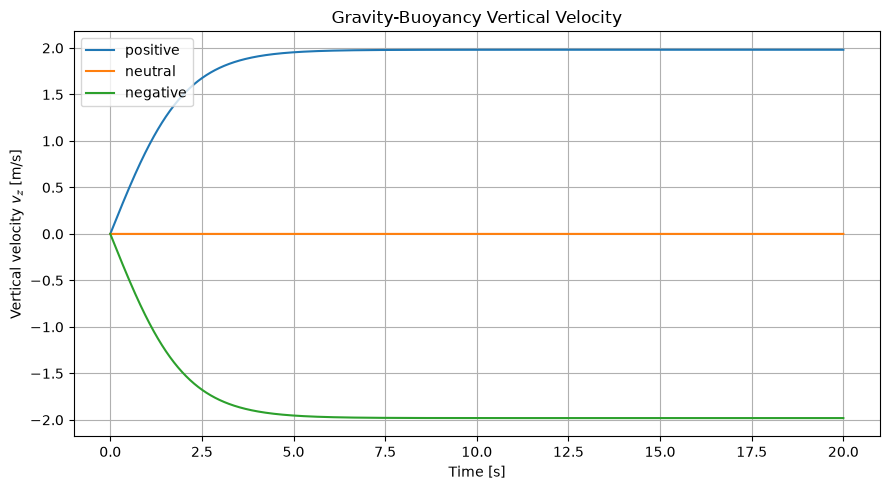

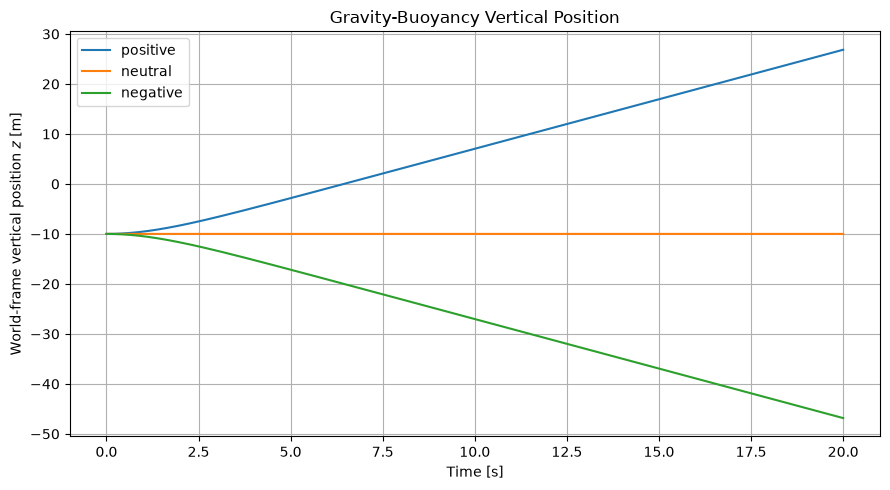

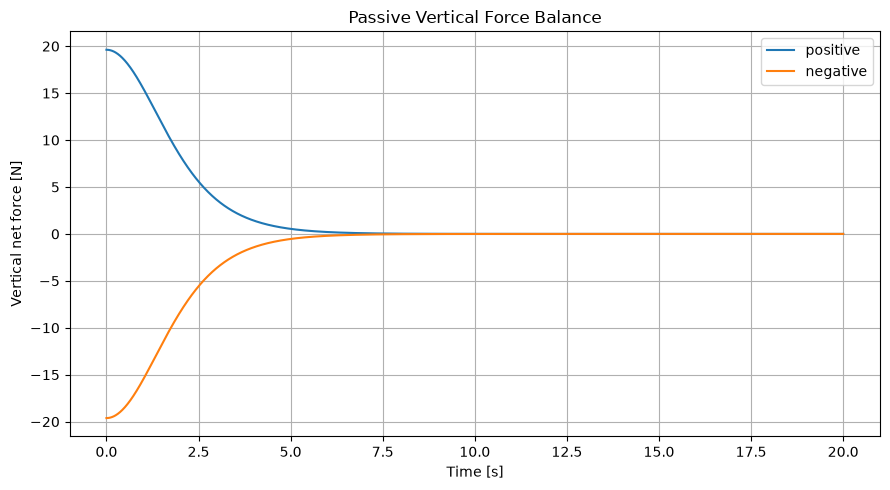


Production-code canonical validation

POSITIVE BUOYANCY
  analytical terminal velocity: 1.9809088823063015
  numerical final velocity: 1.9809088732898426
  final net force z: 1.7860783785295098e-07
  final acceleration z: 8.93039189264755e-09
  final position z: 26.841752824970836

NEUTRAL BUOYANCY
  analytical terminal velocity: 0.0
  numerical final velocity: 0.0
  final net force z: 0.0
  final acceleration z: 0.0
  final position z: -10.0

NEGATIVE BUOYANCY
  analytical terminal velocity: -1.9809088823063015
  numerical final velocity: -1.9809088732898426
  final net force z: -1.7860783785295098e-07
  final acceleration z: -8.93039189264755e-09
  final position z: -46.84175282497082

Generated artifacts:
  results/notebooks/04_buoyancy_gravity/data/buoyancy_gravity_validation.csv
  results/notebooks/04_buoyancy_gravity/plots/vertical_velocity.png
  results/notebooks/04_buoyancy_gravity/plots/vertical_position.png
  results/notebooks/04_buoyancy_gravity/plots/vertical_force_balance

In [11]:
from pathlib import Path
import importlib
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Resolve HydroLab-3D repository and source path
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

src_path = repo_root / "src"

if not src_path.exists():
    raise FileNotFoundError(
        f"HydroLab-3D source directory not found: {src_path}"
    )

src_path_str = str(src_path)

if src_path_str not in sys.path:
    sys.path.insert(0, src_path_str)


# ---------------------------------------------------------------------
# Reload production dynamics package
#
# The running Jupyter kernel may contain the pre-Step-6 version of
# hydrolab3d.dynamics in sys.modules. Invalidate filesystem caches and
# reload the package so its updated __init__.py is executed.
# ---------------------------------------------------------------------

importlib.invalidate_caches()

import hydrolab3d.dynamics as dynamics

dynamics = importlib.reload(dynamics)


# ---------------------------------------------------------------------
# Bind production functions from the freshly reloaded package
# ---------------------------------------------------------------------

gravity_force_prod = dynamics.gravity_force
buoyancy_force_prod = dynamics.buoyancy_force
quadratic_drag_force_prod = dynamics.quadratic_drag_force
acceleration_from_force_prod = dynamics.acceleration_from_force
integrate_velocity_prod = dynamics.integrate_velocity
integrate_position_prod = dynamics.integrate_position


# ---------------------------------------------------------------------
# Verify production-source provenance
# ---------------------------------------------------------------------

function_sources = {
    "gravity_force": Path(
        inspect.getsourcefile(
            gravity_force_prod
        )
    ).resolve(),

    "buoyancy_force": Path(
        inspect.getsourcefile(
            buoyancy_force_prod
        )
    ).resolve(),

    "quadratic_drag_force": Path(
        inspect.getsourcefile(
            quadratic_drag_force_prod
        )
    ).resolve(),

    "acceleration_from_force": Path(
        inspect.getsourcefile(
            acceleration_from_force_prod
        )
    ).resolve(),

    "integrate_velocity": Path(
        inspect.getsourcefile(
            integrate_velocity_prod
        )
    ).resolve(),

    "integrate_position": Path(
        inspect.getsourcefile(
            integrate_position_prod
        )
    ).resolve(),
}

expected_buoyancy_path = (
    src_path
    / "hydrolab3d"
    / "dynamics"
    / "buoyancy.py"
).resolve()

expected_drag_path = (
    src_path
    / "hydrolab3d"
    / "dynamics"
    / "drag.py"
).resolve()

expected_rigid_body_path = (
    src_path
    / "hydrolab3d"
    / "dynamics"
    / "rigid_body.py"
).resolve()

expected_kinematics_path = (
    src_path
    / "hydrolab3d"
    / "dynamics"
    / "kinematics.py"
).resolve()


assert (
    function_sources["gravity_force"]
    == expected_buoyancy_path
)

assert (
    function_sources["buoyancy_force"]
    == expected_buoyancy_path
)

assert (
    function_sources["quadratic_drag_force"]
    == expected_drag_path
)

assert (
    function_sources["acceleration_from_force"]
    == expected_rigid_body_path
)

assert (
    function_sources["integrate_velocity"]
    == expected_rigid_body_path
)

assert (
    function_sources["integrate_position"]
    == expected_kinematics_path
)


print("Production package reload: OK")

print("\nProduction function provenance:")

for name, path in function_sources.items():
    print(
        f"  {name}: "
        f"{path.relative_to(repo_root)}"
    )


# ---------------------------------------------------------------------
# Resolve output directories
# ---------------------------------------------------------------------

output_root = (
    repo_root
    / "results"
    / "notebooks"
    / "04_buoyancy_gravity"
)

data_dir = output_root / "data"
plots_dir = output_root / "plots"

data_dir.mkdir(
    parents=True,
    exist_ok=True,
)

plots_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------
# Canonical production-code configuration
# ---------------------------------------------------------------------

mass = 20.0
rho = 1000.0
g = 9.81
drag_coefficient = 5.0

dt = 0.01
duration = 20.0

num_steps = int(round(duration / dt))

initial_position = np.array([
    0.0,
    0.0,
    -10.0,
])

initial_velocity = np.zeros(3)

neutral_volume = mass / rho

volumes = {
    "positive": 1.10 * neutral_volume,
    "neutral": neutral_volume,
    "negative": 0.90 * neutral_volume,
}


# ---------------------------------------------------------------------
# Run canonical simulation using production functions only
# ---------------------------------------------------------------------

records = []
production_results = {}

for case, displaced_volume in volumes.items():

    gravity = gravity_force_prod(
        mass,
        g,
    )

    buoyancy = buoyancy_force_prod(
        rho,
        displaced_volume,
        g,
    )

    gravity_buoyancy = (
        gravity + buoyancy
    )

    position = initial_position.copy()
    velocity = initial_velocity.copy()

    for step in range(num_steps + 1):

        time = step * dt

        drag = quadratic_drag_force_prod(
            velocity,
            drag_coefficient,
        )

        net_force = (
            gravity
            + buoyancy
            + drag
        )

        acceleration = acceleration_from_force_prod(
            net_force,
            mass,
        )

        records.append({
            "time_s": time,
            "case": case,

            "gravity_fx_N": gravity[0],
            "gravity_fy_N": gravity[1],
            "gravity_fz_N": gravity[2],

            "buoyancy_fx_N": buoyancy[0],
            "buoyancy_fy_N": buoyancy[1],
            "buoyancy_fz_N": buoyancy[2],

            "drag_fx_N": drag[0],
            "drag_fy_N": drag[1],
            "drag_fz_N": drag[2],

            "net_fx_N": net_force[0],
            "net_fy_N": net_force[1],
            "net_fz_N": net_force[2],

            "ax_mps2": acceleration[0],
            "ay_mps2": acceleration[1],
            "az_mps2": acceleration[2],

            "vx_mps": velocity[0],
            "vy_mps": velocity[1],
            "vz_mps": velocity[2],

            "x_m": position[0],
            "y_m": position[1],
            "z_m": position[2],
        })

        if step == num_steps:
            break

        # Preserve validated explicit-Euler ordering:
        # position uses beginning-of-step velocity.
        position = integrate_position_prod(
            position,
            velocity,
            dt,
        )

        velocity = integrate_velocity_prod(
            velocity,
            acceleration,
            dt,
        )

    production_results[case] = {
        "gravity": gravity,
        "buoyancy": buoyancy,
        "gravity_buoyancy": gravity_buoyancy,
    }


# ---------------------------------------------------------------------
# Build and save canonical dataframe
# ---------------------------------------------------------------------

results_df = pd.DataFrame(records)

csv_path = (
    data_dir
    / "buoyancy_gravity_validation.csv"
)

results_df.to_csv(
    csv_path,
    index=False,
)


# ---------------------------------------------------------------------
# Analytical terminal velocities
# ---------------------------------------------------------------------

terminal_expected = {}
terminal_actual = {}

for case, result in production_results.items():

    force_z = result[
        "gravity_buoyancy"
    ][2]

    if np.isclose(
        force_z,
        0.0,
        atol=1e-12,
        rtol=0.0,
    ):
        expected_velocity = 0.0
    else:
        expected_velocity = (
            np.sign(force_z)
            * np.sqrt(
                abs(force_z)
                / drag_coefficient
            )
        )

    case_df = results_df[
        results_df["case"] == case
    ]

    actual_velocity = float(
        case_df.iloc[-1]["vz_mps"]
    )

    terminal_expected[case] = (
        expected_velocity
    )

    terminal_actual[case] = (
        actual_velocity
    )


# ---------------------------------------------------------------------
# Terminal-speed validation
# ---------------------------------------------------------------------

for case in (
    "positive",
    "negative",
):

    assert np.isclose(
        terminal_actual[case],
        terminal_expected[case],
        rtol=2e-3,
        atol=2e-3,
    )


assert np.isclose(
    abs(terminal_actual["positive"]),
    abs(terminal_actual["negative"]),
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Neutral-buoyancy validation
# ---------------------------------------------------------------------

neutral_df = results_df[
    results_df["case"] == "neutral"
]

assert np.allclose(
    neutral_df[
        [
            "vx_mps",
            "vy_mps",
            "vz_mps",
        ]
    ].to_numpy(),
    0.0,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    neutral_df[
        [
            "x_m",
            "y_m",
        ]
    ].to_numpy(),
    0.0,
    atol=1e-12,
    rtol=0.0,
)

assert np.allclose(
    neutral_df["z_m"].to_numpy(),
    initial_position[2],
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Equilibrium validation
# ---------------------------------------------------------------------

for case in (
    "positive",
    "negative",
):

    case_df = results_df[
        results_df["case"] == case
    ]

    final_row = case_df.iloc[-1]

    assert abs(
        final_row["net_fz_N"]
    ) < 0.05

    assert abs(
        final_row["az_mps2"]
    ) < 0.003


# ---------------------------------------------------------------------
# Direction validation
# ---------------------------------------------------------------------

positive_df = results_df[
    results_df["case"] == "positive"
]

negative_df = results_df[
    results_df["case"] == "negative"
]

assert (
    positive_df.iloc[-1]["vz_mps"]
    > 0.0
)

assert (
    positive_df.iloc[-1]["z_m"]
    > initial_position[2]
)

assert (
    negative_df.iloc[-1]["vz_mps"]
    < 0.0
)

assert (
    negative_df.iloc[-1]["z_m"]
    < initial_position[2]
)


# ---------------------------------------------------------------------
# Axis isolation
# ---------------------------------------------------------------------

assert np.allclose(
    results_df[
        [
            "x_m",
            "y_m",
            "vx_mps",
            "vy_mps",
            "ax_mps2",
            "ay_mps2",
            "gravity_fx_N",
            "gravity_fy_N",
            "buoyancy_fx_N",
            "buoyancy_fy_N",
            "drag_fx_N",
            "drag_fy_N",
            "net_fx_N",
            "net_fy_N",
        ]
    ].to_numpy(),
    0.0,
    atol=1e-12,
    rtol=0.0,
)


# ---------------------------------------------------------------------
# Finite-state validation
# ---------------------------------------------------------------------

numeric_columns = [
    column
    for column in results_df.columns
    if column != "case"
]

numeric_data = results_df[
    numeric_columns
].to_numpy(dtype=float)

assert np.all(
    np.isfinite(numeric_data)
)


# ---------------------------------------------------------------------
# Plot 1 - Vertical velocity
# ---------------------------------------------------------------------

velocity_plot_path = (
    plots_dir
    / "vertical_velocity.png"
)

plt.figure(figsize=(9, 5))

for case in (
    "positive",
    "neutral",
    "negative",
):

    case_df = results_df[
        results_df["case"] == case
    ]

    plt.plot(
        case_df["time_s"],
        case_df["vz_mps"],
        label=case,
    )

plt.xlabel("Time [s]")
plt.ylabel(
    "Vertical velocity $v_z$ [m/s]"
)
plt.title(
    "Gravity-Buoyancy Vertical Velocity"
)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    velocity_plot_path,
    dpi=160,
)

plt.show()
plt.close()


# ---------------------------------------------------------------------
# Plot 2 - Vertical position
# ---------------------------------------------------------------------

position_plot_path = (
    plots_dir
    / "vertical_position.png"
)

plt.figure(figsize=(9, 5))

for case in (
    "positive",
    "neutral",
    "negative",
):

    case_df = results_df[
        results_df["case"] == case
    ]

    plt.plot(
        case_df["time_s"],
        case_df["z_m"],
        label=case,
    )

plt.xlabel("Time [s]")
plt.ylabel(
    "World-frame vertical position $z$ [m]"
)
plt.title(
    "Gravity-Buoyancy Vertical Position"
)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    position_plot_path,
    dpi=160,
)

plt.show()
plt.close()


# ---------------------------------------------------------------------
# Plot 3 - Vertical net-force convergence
# ---------------------------------------------------------------------

force_plot_path = (
    plots_dir
    / "vertical_force_balance.png"
)

plt.figure(figsize=(9, 5))

for case in (
    "positive",
    "negative",
):

    case_df = results_df[
        results_df["case"] == case
    ]

    plt.plot(
        case_df["time_s"],
        case_df["net_fz_N"],
        label=case,
    )

plt.xlabel("Time [s]")
plt.ylabel(
    "Vertical net force [N]"
)
plt.title(
    "Passive Vertical Force Balance"
)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig(
    force_plot_path,
    dpi=160,
)

plt.show()
plt.close()


# ---------------------------------------------------------------------
# Artifact existence validation
# ---------------------------------------------------------------------

artifact_paths = [
    csv_path,
    velocity_plot_path,
    position_plot_path,
    force_plot_path,
]

for artifact_path in artifact_paths:

    assert artifact_path.exists()

    assert (
        artifact_path.stat().st_size > 0
    )


# ---------------------------------------------------------------------
# Final production-code report
# ---------------------------------------------------------------------

print(
    "\nProduction-code canonical validation"
)

for case in (
    "positive",
    "neutral",
    "negative",
):

    case_df = results_df[
        results_df["case"] == case
    ]

    final_row = case_df.iloc[-1]

    print(f"\n{case.upper()} BUOYANCY")

    print(
        "  analytical terminal velocity:",
        terminal_expected[case],
    )

    print(
        "  numerical final velocity:",
        terminal_actual[case],
    )

    print(
        "  final net force z:",
        final_row["net_fz_N"],
    )

    print(
        "  final acceleration z:",
        final_row["az_mps2"],
    )

    print(
        "  final position z:",
        final_row["z_m"],
    )


print("\nGenerated artifacts:")

for artifact_path in artifact_paths:

    print(
        " ",
        artifact_path.relative_to(
            repo_root
        ),
    )


print(
    "\nStep 7 production reload, canonical "
    "simulation, and artifact generation: PASS"
)

## Step 8 - Final Repository Regression and Engineering Handoff Audit

The gravity and buoyancy physics, nonlinear drag coupling, production promotion, production re-import, and persistent validation artifacts have now all passed.

Before Notebook 04 can be closed, we perform one final **read-only engineering audit**.

This step does not introduce new physics and does not modify production code.

Its purpose is to verify that the repository actually contains the implementation and evidence that Notebook 05 will inherit.

---

### Validated Translational Stack

Notebook 04 has extended the passive translational dynamics from:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
$$

to:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

with:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

and:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

This final audit must establish that these components now exist as reusable production capabilities rather than only notebook-local experiments.

---

### Repository State to Verify

The following production files must exist and be non-empty:

```text
src/hydrolab3d/dynamics/kinematics.py
src/hydrolab3d/dynamics/rigid_body.py
src/hydrolab3d/dynamics/drag.py
src/hydrolab3d/dynamics/buoyancy.py
src/hydrolab3d/dynamics/__init__.py
```

The buoyancy regression file must also exist:

```text
tests/test_buoyancy.py
```

The package interface must expose:

```text
gravity_force
buoyancy_force
quadratic_drag_force
acceleration_from_force
integrate_velocity
integrate_position
```

---

### Persistent Validation Evidence

Notebook 04 must leave behind exactly the scientifically useful artifacts generated in Step 7:

```text
results/notebooks/04_buoyancy_gravity/
├── data/
│   └── buoyancy_gravity_validation.csv
└── plots/
    ├── vertical_velocity.png
    ├── vertical_position.png
    └── vertical_force_balance.png
```

Each artifact must exist and be non-empty.

The canonical CSV must contain all three buoyancy cases:

```text
positive
neutral
negative
```

and contain finite numerical data.

---

### Regression Requirement

The complete HydroLab-3D test suite must still pass from a fresh subprocess environment with the repository `src/` directory available through `PYTHONPATH`.

The validated Step 6 baseline was:

```text
51 passed
```

The final audit should preserve that result.

---

### Engineering Handoff to Notebook 05

If this step passes, Notebook 05 may assume that the following capabilities are already validated and reusable:

```text
3D position propagation
        +
force → acceleration conversion
        +
velocity integration
        +
quadratic hydrodynamic drag
        +
gravity
        +
buoyancy
```

The next notebook therefore does not need to reopen passive translational-force validation.

It may begin from:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

and introduce actuator-generated thrust.

Conceptually:

```text
command
   ↓
thruster model
   ↓
generated force
   ↓
validated passive translational dynamics
   ↓
acceleration
   ↓
velocity
   ↓
position
```

---

### Important Remaining Physical Boundary

Notebook 04 models a fully submerged vehicle with constant displaced volume.

It does **not** model:

- water-surface contact;
- partial emergence;
- displacement changing with immersion;
- hydrostatic free-surface effects.

Therefore a positively buoyant simulated vehicle may mathematically continue through:

$$
z=0
$$

even though $z=0$ represents the nominal water surface in the wider HydroLab-3D world convention.

This behavior is acceptable within Notebook 04 because the validation target is the submerged gravity-buoyancy force model, not surface interaction.

The limitation must be documented explicitly in the final conclusion.

---

### Success Criterion

Step 8 passes only if:

1. all required production modules exist and are non-empty;
2. all required production functions are importable from the package interface;
3. all four Notebook 04 artifacts exist and are non-empty;
4. the CSV contains positive, neutral, and negative cases;
5. the CSV contains only finite numerical values;
6. the complete regression suite passes;
7. the final repository state is sufficient for `05_thruster_model.ipynb` to begin without revalidating gravity, buoyancy, drag, acceleration, velocity integration, or position propagation.

No files should be modified during this audit.

In [12]:
from pathlib import Path
import importlib
import os
import subprocess
import sys

import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Resolve repository
# ---------------------------------------------------------------------

repo_root = Path.cwd().resolve()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

src_path = repo_root / "src"

if not src_path.exists():
    raise FileNotFoundError(
        f"HydroLab-3D source directory not found: {src_path}"
    )


# ---------------------------------------------------------------------
# 1. Production-file audit
# ---------------------------------------------------------------------

required_production_files = [
    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "kinematics.py",

    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "rigid_body.py",

    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "drag.py",

    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "buoyancy.py",

    repo_root
    / "src"
    / "hydrolab3d"
    / "dynamics"
    / "__init__.py",

    repo_root
    / "tests"
    / "test_buoyancy.py",
]

print("=" * 80)
print("PRODUCTION FILE AUDIT")
print("=" * 80)

for path in required_production_files:

    assert path.exists(), (
        f"Required file does not exist: {path}"
    )

    assert path.is_file(), (
        f"Required path is not a file: {path}"
    )

    assert path.stat().st_size > 0, (
        f"Required file is empty: {path}"
    )

    print(
        "[OK]",
        path.relative_to(repo_root),
    )


# ---------------------------------------------------------------------
# 2. Package-interface audit
# ---------------------------------------------------------------------

src_path_str = str(src_path)

if src_path_str not in sys.path:
    sys.path.insert(0, src_path_str)

importlib.invalidate_caches()

import hydrolab3d.dynamics as dynamics

dynamics = importlib.reload(dynamics)

required_exports = [
    "gravity_force",
    "buoyancy_force",
    "quadratic_drag_force",
    "acceleration_from_force",
    "integrate_velocity",
    "integrate_position",
]

print("\n" + "=" * 80)
print("DYNAMICS PACKAGE EXPORT AUDIT")
print("=" * 80)

for name in required_exports:

    assert hasattr(
        dynamics,
        name,
    ), (
        f"Missing dynamics package export: {name}"
    )

    obj = getattr(
        dynamics,
        name,
    )

    assert callable(obj), (
        f"Dynamics export is not callable: {name}"
    )

    print(
        "[OK]",
        name,
    )


# ---------------------------------------------------------------------
# 3. Artifact audit
# ---------------------------------------------------------------------

output_root = (
    repo_root
    / "results"
    / "notebooks"
    / "04_buoyancy_gravity"
)

csv_path = (
    output_root
    / "data"
    / "buoyancy_gravity_validation.csv"
)

artifact_paths = [
    csv_path,
    output_root
    / "plots"
    / "vertical_velocity.png",
    output_root
    / "plots"
    / "vertical_position.png",
    output_root
    / "plots"
    / "vertical_force_balance.png",
]

print("\n" + "=" * 80)
print("NOTEBOOK 04 ARTIFACT AUDIT")
print("=" * 80)

for path in artifact_paths:

    assert path.exists(), (
        f"Expected artifact missing: {path}"
    )

    assert path.is_file(), (
        f"Artifact path is not a file: {path}"
    )

    assert path.stat().st_size > 0, (
        f"Artifact is empty: {path}"
    )

    print(
        "[OK]",
        path.relative_to(repo_root),
        f"({path.stat().st_size} bytes)",
    )


# ---------------------------------------------------------------------
# 4. Canonical CSV audit
# ---------------------------------------------------------------------

audit_df = pd.read_csv(
    csv_path
)

expected_cases = {
    "positive",
    "neutral",
    "negative",
}

actual_cases = set(
    audit_df["case"].unique()
)

assert actual_cases == expected_cases, (
    "Canonical CSV does not contain exactly "
    "the expected buoyancy cases."
)

numeric_columns = [
    column
    for column in audit_df.columns
    if column != "case"
]

numeric_values = audit_df[
    numeric_columns
].to_numpy(dtype=float)

assert np.all(
    np.isfinite(numeric_values)
), (
    "Canonical CSV contains NaN or infinite values."
)

print("\n" + "=" * 80)
print("CANONICAL CSV AUDIT")
print("=" * 80)

print(
    "Rows:",
    len(audit_df),
)

print(
    "Cases:",
    sorted(actual_cases),
)

print(
    "Finite numerical values:",
    "YES",
)


# ---------------------------------------------------------------------
# 5. Final fresh-process regression suite
# ---------------------------------------------------------------------

test_env = os.environ.copy()

existing_pythonpath = test_env.get(
    "PYTHONPATH",
    "",
)

if existing_pythonpath:
    test_env["PYTHONPATH"] = (
        str(src_path)
        + os.pathsep
        + existing_pythonpath
    )
else:
    test_env["PYTHONPATH"] = str(src_path)

print("\n" + "=" * 80)
print("FINAL HYDROLAB-3D REGRESSION SUITE")
print("=" * 80)

complete = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        "-q",
    ],
    cwd=repo_root,
    env=test_env,
    text=True,
    capture_output=True,
)

print(complete.stdout)

if complete.stderr:
    print(complete.stderr)

assert complete.returncode == 0, (
    "Final HydroLab-3D regression suite failed."
)


# ---------------------------------------------------------------------
# 6. Handoff summary
# ---------------------------------------------------------------------

print("=" * 80)
print("NOTEBOOK 04 ENGINEERING HANDOFF")
print("=" * 80)

print(
    "Validated production capabilities:"
)

for capability in [
    "3D position propagation",
    "force-to-acceleration conversion",
    "velocity integration",
    "quadratic hydrodynamic drag",
    "gravity force",
    "hydrostatic buoyancy force",
]:
    print(
        "  [READY]",
        capability,
    )

print(
    "\nNext notebook:"
)

print(
    "  05_thruster_model.ipynb"
)

print(
    "\nStep 8 final repository regression "
    "and engineering handoff audit: PASS"
)

PRODUCTION FILE AUDIT
[OK] src/hydrolab3d/dynamics/kinematics.py
[OK] src/hydrolab3d/dynamics/rigid_body.py
[OK] src/hydrolab3d/dynamics/drag.py
[OK] src/hydrolab3d/dynamics/buoyancy.py
[OK] src/hydrolab3d/dynamics/__init__.py
[OK] tests/test_buoyancy.py

DYNAMICS PACKAGE EXPORT AUDIT
[OK] gravity_force
[OK] buoyancy_force
[OK] quadratic_drag_force
[OK] acceleration_from_force
[OK] integrate_velocity
[OK] integrate_position

NOTEBOOK 04 ARTIFACT AUDIT
[OK] results/notebooks/04_buoyancy_gravity/data/buoyancy_gravity_validation.csv (1102827 bytes)
[OK] results/notebooks/04_buoyancy_gravity/plots/vertical_velocity.png (65550 bytes)
[OK] results/notebooks/04_buoyancy_gravity/plots/vertical_position.png (82474 bytes)
[OK] results/notebooks/04_buoyancy_gravity/plots/vertical_force_balance.png (58221 bytes)

CANONICAL CSV AUDIT
Rows: 6003
Cases: ['negative', 'neutral', 'positive']
Finite numerical values: YES

FINAL HYDROLAB-3D REGRESSION SUITE
................................................

# Conclusion

## What Was Implemented

Notebook 04 introduced the gravity and buoyancy layer required for physically meaningful vertical underwater motion in HydroLab-3D.

The validated passive translational force balance is now:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

with quadratic drag:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

gravity:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-mg
\end{bmatrix}
$$

and hydrostatic buoyancy:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
\rho gV
\end{bmatrix}
$$

under the established HydroLab-3D convention:

$$
+z_W
=
\text{upward}
$$

The combined gravity-buoyancy contribution is therefore:

$$
\mathbf{F}_{GB}
=
\mathbf{F}_G
+
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
g(\rho V-m)
\end{bmatrix}
$$

Two reusable production functions were added:

```text
gravity_force()
buoyancy_force()
```

The implementation was promoted into:

`src/hydrolab3d/dynamics/buoyancy.py`

and exported through:

`src/hydrolab3d/dynamics/__init__.py`

Focused automated regression coverage was added in:

`tests/test_buoyancy.py`

The implementation continues to use the previously validated production functions for:

- force-to-acceleration conversion;
- velocity integration;
- position integration;
- quadratic hydrodynamic drag.

---

## What Was Validated

Notebook 04 validated the gravity and buoyancy layer progressively from algebraic force calculations to the complete passive translational simulation.

### Force-Level Validation

For:

$$
m=20\text{ kg}
$$

and:

$$
g=9.81\text{ m/s}^2
$$

the gravitational force was:

$$
\mathbf{F}_G
=
\begin{bmatrix}
0\\
0\\
-196.2
\end{bmatrix}
\text{ N}
$$

For:

$$
\rho=1000\text{ kg/m}^3
$$

and:

$$
V=0.020\text{ m}^3
$$

the buoyancy force was:

$$
\mathbf{F}_B
=
\begin{bmatrix}
0\\
0\\
196.2
\end{bmatrix}
\text{ N}
$$

which produced exact neutral buoyancy:

$$
\mathbf{F}_G+\mathbf{F}_B
=
\mathbf{0}
$$

A $\pm10\%$ displaced-volume variation produced symmetric gravity-buoyancy imbalances:

$$
F_{GB,z}
=
+19.62\text{ N}
$$

for positive buoyancy and:

$$
F_{GB,z}
=
-19.62\text{ N}
$$

for negative buoyancy.

---

### Scaling Validation

Gravity was verified to scale linearly with:

$$
m
$$

and:

$$
g
$$

Buoyancy was verified to scale linearly with:

$$
\rho
$$

$$
V
$$

and:

$$
g
$$

The expected buoyancy-state accelerations for the 20 kg vehicle were:

$$
a_{z,+}
=
+0.981\text{ m/s}^2
$$

$$
a_{z,0}
=
0
$$

$$
a_{z,-}
=
-0.981\text{ m/s}^2
$$

No unintended horizontal acceleration was observed.

The local implementation also rejected all deliberately invalid physical inputs tested during development.

The dedicated validation step rejected:

```text
16 / 16 invalid parameter cases
```

---

### Constant-Acceleration Translational Validation

Before reintroducing drag, positive, neutral, and negative buoyancy were propagated through the inherited HydroLab-3D translational dynamics chain.

Using:

$$
\Delta t=0.01\text{ s}
$$

for:

$$
5\text{ s}
$$

the positive-buoyancy case reached:

$$
v_z
=
+4.905\text{ m/s}
$$

and:

$$
z
=
+2.237975\text{ m}
$$

from an initial position:

$$
z_0=-10\text{ m}
$$

The neutral case remained exactly at:

$$
v_z=0
$$

and:

$$
z=-10\text{ m}
$$

The negative-buoyancy case reached:

$$
v_z
=
-4.905\text{ m/s}
$$

and:

$$
z
=
-22.237975\text{ m}
$$

The positive and negative cases were symmetric, and the numerical trajectory matched the expected discrete explicit-Euler solution.

---

### Quadratic-Drag Coupling

The gravity-buoyancy layer was then combined with the previously validated quadratic drag model:

$$
\mathbf{F}_D
=
-C_D
\|\mathbf{v}\|
\mathbf{v}
$$

using:

$$
C_D=5.0
$$

For the symmetric:

$$
|F_{GB,z}|=19.62\text{ N}
$$

cases, the analytical vertical terminal speed was:

$$
|v_{z,\infty}|
=
\sqrt{
\frac{19.62}{5.0}
}
$$

which gave:

$$
|v_{z,\infty}|
=
1.9809088823063015\text{ m/s}
$$

The production simulation produced:

$$
v_{z,\text{final}}
=
+1.9809088732898426\text{ m/s}
$$

for positive buoyancy and:

$$
v_{z,\text{final}}
=
-1.9809088732898426\text{ m/s}
$$

for negative buoyancy.

The numerical and analytical values therefore agreed extremely closely.

---

## Key Results

The final canonical production simulation used:

$$
m=20\text{ kg}
$$

$$
\rho=1000\text{ kg/m}^3
$$

$$
g=9.81\text{ m/s}^2
$$

$$
C_D=5.0
$$

$$
\Delta t=0.01\text{ s}
$$

and:

$$
T=20\text{ s}
$$

### Positive Buoyancy

Analytical terminal velocity:

$$
v_{z,\infty}
=
1.9809088823063015\text{ m/s}
$$

Numerical final velocity:

$$
v_z
=
1.9809088732898426\text{ m/s}
$$

Final vertical net force:

$$
F_{net,z}
=
1.7860783785295098\times10^{-7}\text{ N}
$$

Final vertical acceleration:

$$
a_z
=
8.93039189264755\times10^{-9}\text{ m/s}^2
$$

Final simulated vertical position:

$$
z
=
26.841752824970836\text{ m}
$$

---

### Neutral Buoyancy

Analytical terminal velocity:

$$
v_{z,\infty}=0
$$

Numerical final velocity:

$$
v_z=0
$$

Final vertical net force:

$$
F_{net,z}=0
$$

Final vertical acceleration:

$$
a_z=0
$$

Final position:

$$
z=-10\text{ m}
$$

The neutral case remained exactly stationary for the complete simulation.

---

### Negative Buoyancy

Analytical terminal velocity:

$$
v_{z,\infty}
=
-1.9809088823063015\text{ m/s}
$$

Numerical final velocity:

$$
v_z
=
-1.9809088732898426\text{ m/s}
$$

Final vertical net force:

$$
F_{net,z}
=
-1.7860783785295098\times10^{-7}\text{ N}
$$

Final vertical acceleration:

$$
a_z
=
-8.93039189264755\times10^{-9}\text{ m/s}^2
$$

Final simulated vertical position:

$$
z
=
-46.84175282497082\text{ m}
$$

The positive and negative terminal-speed results were symmetric to numerical precision.

---

## Production-Code Promotion

The validated notebook-local gravity and buoyancy implementations were promoted into:

`src/hydrolab3d/dynamics/buoyancy.py`

The production module now provides:

```text
gravity_force()
buoyancy_force()
```

The package exports were updated in:

`src/hydrolab3d/dynamics/__init__.py`

so the dynamics package exposes:

```text
gravity_force
buoyancy_force
quadratic_drag_force
acceleration_from_force
integrate_velocity
integrate_position
```

Focused production regression tests were added to:

`tests/test_buoyancy.py`

The buoyancy-specific regression suite completed with:

```text
20 passed
```

The complete HydroLab-3D regression suite completed with:

```text
51 passed
```

This confirms that gravity and buoyancy were added without regressing the previously validated kinematics, dynamics, orientation-supporting infrastructure, or drag behavior.

---

## Generated Outputs

Notebook 04 generated the following persistent validation artifacts.

### Numerical Data

`results/notebooks/04_buoyancy_gravity/data/buoyancy_gravity_validation.csv`

The canonical CSV contains:

```text
6003 rows
```

covering all three cases:

```text
negative
neutral
positive
```

The stored numerical quantities were verified to contain only finite values.

---

### Validation Figures

`results/notebooks/04_buoyancy_gravity/plots/vertical_velocity.png`

This figure shows:

- positive buoyancy converging toward a finite positive terminal speed;
- neutral buoyancy remaining at zero velocity;
- negative buoyancy converging toward the equal-magnitude negative terminal speed.

---

`results/notebooks/04_buoyancy_gravity/plots/vertical_position.png`

This figure shows:

- sustained upward displacement for positive buoyancy;
- constant depth for neutral buoyancy;
- sustained downward displacement for negative buoyancy.

---

`results/notebooks/04_buoyancy_gravity/plots/vertical_force_balance.png`

This figure shows the positive and negative net vertical forces decaying from approximately:

$$
\pm19.62\text{ N}
$$

toward:

$$
0\text{ N}
$$

as quadratic drag grows and balances the gravity-buoyancy imbalance.

---

## Output Location

All Notebook 04 persistent outputs are stored under:

`results/notebooks/04_buoyancy_gravity/`

with the final structure:

```text
results/notebooks/04_buoyancy_gravity/
├── data/
│   └── buoyancy_gravity_validation.csv
└── plots/
    ├── vertical_velocity.png
    ├── vertical_position.png
    └── vertical_force_balance.png
```

---

## Important Observations

### Neutral Buoyancy Is a Force Balance, Not a Velocity Constraint

Neutral buoyancy means:

$$
\mathbf{F}_G+\mathbf{F}_B
=
\mathbf{0}
$$

It does not inherently mean that the vehicle must have zero velocity.

The canonical neutral case remains stationary because it begins at rest and therefore also has:

$$
\mathbf{F}_D=\mathbf{0}
$$

A neutrally buoyant vehicle given an initial velocity would still decelerate because of hydrodynamic drag.

---

### Quadratic Drag Produces a Finite Passive Vertical Speed

Without drag, a constant buoyancy imbalance produces constant acceleration and unbounded velocity growth in the reduced model.

With quadratic drag:

$$
F_D\propto v^2
$$

so increasing speed increases resistance until:

$$
\mathbf{F}_G
+
\mathbf{F}_B
+
\mathbf{F}_D
\approx
\mathbf{0}
$$

The simulation therefore transitions naturally from initial acceleration toward a finite terminal speed.

---

### Force Balance Was Reached Numerically

For the moving cases, the final vertical net-force magnitude was approximately:

$$
1.79\times10^{-7}\text{ N}
$$

and the final acceleration magnitude was approximately:

$$
8.93\times10^{-9}\text{ m/s}^2
$$

These values are effectively zero at the numerical scale of this experiment and strongly confirm convergence toward the analytical passive equilibrium.

---

### No Horizontal Contamination Was Observed

Pure vertical gravity and buoyancy cases produced no unintended:

$$
x
$$

or:

$$
y
$$

acceleration, velocity, or position evolution.

This confirms that the reduced restoring-force layer is correctly isolated to the world vertical axis.

---

### The Positive Case Crosses the Nominal Water Surface

The canonical positive-buoyancy simulation begins at:

$$
z=-10\text{ m}
$$

but reaches:

$$
z\approx26.84\text{ m}
$$

after 20 seconds.

This is not a failure of the gravity-buoyancy equations.

Notebook 04 assumes a **fully submerged vehicle with constant displaced volume** throughout the experiment.

The simulation therefore continues applying full hydrostatic buoyancy after the state crosses:

$$
z=0
$$

even though the wider HydroLab-3D world convention treats:

$$
z=0
$$

as the nominal water surface.

Surface interaction is intentionally outside this notebook's scope.

---

## Current Limitations

Notebook 04 remains a reduced translational model.

It does not yet include:

- water-surface collision or emergence behavior;
- partial submergence;
- buoyancy variation with immersed volume;
- free-surface hydrostatics;
- separate centers of gravity and buoyancy;
- buoyancy-generated moments;
- gravity-generated rotational restoring moments;
- rotational rigid-body dynamics;
- added mass;
- Coriolis and centripetal marine terms;
- ocean currents;
- thruster dynamics;
- actuator saturation;
- actuator lag;
- controllers;
- sensors;
- ROS 2;
- reinforcement learning.

Gravity and buoyancy are currently assumed to act through a single translational center.

Therefore this notebook validates **restoring forces only**, not restoring moments.

---

## How This Result Will Be Used

Notebook 04 completes the passive reduced-order translational force stack required before actuator modeling.

HydroLab-3D now has validated reusable components for:

```text
3D position propagation
        +
force → acceleration conversion
        +
velocity integration
        +
quadratic hydrodynamic drag
        +
gravity
        +
buoyancy
```

The validated dynamics lineage is therefore:

```text
position integration
        ↓
reference-frame infrastructure
        ↓
force-driven translational dynamics
        ↓
quadratic drag
        ↓
gravity + buoyancy
        ↓
thruster-generated force
```

The current translational force balance available to downstream development is:

$$
\boxed{
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
}
$$

Notebook 05 may treat the passive physics terms as established dependencies.

---

## Next Notebook

The next development notebook is:

`05_thruster_model.ipynb`

Notebook 05 will introduce actuator-generated thrust into the already validated translational dynamics stack.

Conceptually:

```text
command
   ↓
thruster model
   ↓
generated force
   ↓
validated drag + gravity + buoyancy
   ↓
net force
   ↓
acceleration
   ↓
velocity
   ↓
position
```

Notebook 05 therefore does **not** need to revalidate:

- gravity;
- buoyancy;
- quadratic drag;
- force-to-acceleration conversion;
- velocity integration;
- position propagation.

It may begin directly from:

$$
m\dot{\mathbf{v}}
=
\mathbf{F}_{applied}
+
\mathbf{F}_D
+
\mathbf{F}_G
+
\mathbf{F}_B
$$

and replace the abstract applied-force term with an explicit actuator model.

Notebook 04 therefore completes the **passive vertical-force foundation** of HydroLab-3D and hands the simulator to the next layer: controlled propulsion.

---